# EllipseNet: Advancing Object Detection with Elliptical Anchor Boxes

**Applied Machine Learning - Final Term Project**

This is a self-contained submission notebook. It includes the dataset conversion, CNN layers, model, loss, backpropagation, optimizer, training loop, evaluation code, graphs, and image visualizations in one `.ipynb` file.

The detector is YOLO-style, but it predicts oriented ellipses instead of rectangular boxes. Each anchor predicts:

`[confidence, cx, cy, a, b, theta, class logits]`

The implementation uses NumPy matrix operations only. It does not use any deep-learning framework, autograd system, `GradientTape`-style API, or automatic differentiation framework.


## Project Requirements Covered

- **Step 1:** YOLO theory, anchor geometry, and why ellipse anchors are useful.
- **Step 2:** Pascal VOC annotation conversion from rectangles to ellipse-compatible targets.
- **Step 3:** Custom NumPy CNN with convolution, max pooling, nonlinearities, 1x1 convolutions, manual backpropagation, ellipse-IoU, and custom loss.
- **Step 4:** Training plan with custom Adam, learning-rate scheduling, checkpoints, and refinement notes.
- **Step 5:** Precision, recall, mAP, ellipse-IoU evaluation, PR/AP graphs, and prediction overlays.

The notebook defaults to **not retraining** so it opens quickly and displays saved results. Set `RUN_TRAINING = True` or `RUN_EVALUATION = True` in the marked cells to recompute them.


In [ ]:

# Global setup: standard library + NumPy/Pillow/Matplotlib only.
import csv
import json
import os
import sys
import time
import xml.etree.ElementTree as ET
from collections import defaultdict
from pathlib import Path

import numpy as np
from PIL import Image

os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/ellipsenet_matplotlib')
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Ellipse as MplEllipse

# Make paths work whether Jupyter is launched from the repo root or EllipseNet_Complete.
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'EllipseNet_Final.ipynb').exists():
    candidate = PROJECT_DIR / 'EllipseNet_Complete'
    if candidate.exists():
        PROJECT_DIR = candidate
os.chdir(PROJECT_DIR)

os.makedirs('figures', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
print('Notebook working directory:', PROJECT_DIR)


## Step 1 - YOLO Foundation and Ellipse Redesign

YOLO divides an image into an `S x S` grid. Each grid cell predicts `B` anchors. Standard YOLO localization uses rectangles, commonly represented as `(x, y, w, h)`. EllipseNet keeps the YOLO-style grid, objectness score, class score, and anchor assignment idea, but replaces the box geometry with ellipse geometry:

`(cx, cy, a, b, theta)`

- `cx, cy`: normalized ellipse center.
- `a, b`: normalized semi-major/semi-minor axis lengths.
- `theta`: orientation angle in radians.

This is useful for elongated, slanted, rounded, or irregularly posed objects where a rectangle includes a lot of background. The backbone and detection-head pattern can remain YOLO-like, but geometry-dependent pieces must change: target conversion, output decoding, localization loss, IoU, NMS, and mAP matching.


## Step 2 - Dataset Customization and Annotation Conversion

Pascal VOC provides rectangular object annotations. For EllipseNet, each VOC rectangle is converted to an ellipse target centered at the same position:

`cx = (xmin + xmax) / (2W)`

`cy = (ymin + ymax) / (2H)`

`a = (xmax - xmin) / (2W)`

`b = (ymax - ymin) / (2H)`

`theta = 0` for the original unrotated image.

Rotation augmentation then creates nonzero orientation examples by rotating the image and updating ellipse center/orientation targets.


In [ ]:
# Dataset loading and VOC-to-ellipse conversion utilities.
"""
EllipseNet dataset utilities for Pascal VOC 2012.

This module keeps the training pipeline focused on the project dataset:
Pascal VOC XML annotations are converted to ellipse targets, and training
samples can expose deterministic rotated variants to introduce non-zero theta.
"""

import csv
import os
import xml.etree.ElementTree as ET
from collections import defaultdict

import numpy as np
from PIL import Image


VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car", "cat",
    "chair", "cow", "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor",
]

DEFAULT_SELECTED_CLASSES = ("person", "car", "dog")
DEFAULT_ROTATION_ANGLES = (0.0, -20.0, -10.0, 10.0, 20.0)
DEFAULT_VOC_SEARCH_ROOT = "/Users/haile/Downloads/archive"


def bbox_to_ellipse(xmin, ymin, xmax, ymax, img_w, img_h):
    """Convert a VOC box to a normalized axis-aligned ellipse."""
    cx = ((xmin + xmax) * 0.5) / img_w
    cy = ((ymin + ymax) * 0.5) / img_h
    a = ((xmax - xmin) * 0.5) / img_w
    b = ((ymax - ymin) * 0.5) / img_h
    return cx, cy, a, b, 0.0


def normalise_theta(theta):
    """Normalize ellipse orientation to [0, pi)."""
    return float(theta % np.pi)


def find_voc_root(search_root=DEFAULT_VOC_SEARCH_ROOT):
    """
    Locate a VOC directory containing JPEGImages, Annotations, and ImageSets.

    The Kaggle archive used for this project has nested folders, so callers can
    pass either /Users/haile/Downloads/archive or the final VOC2012 directory.
    """
    required = ("JPEGImages", "Annotations", "ImageSets")
    if all(os.path.isdir(os.path.join(search_root, name)) for name in required):
        return search_root

    for root, dirs, _ in os.walk(search_root):
        if all(name in dirs for name in required):
            return root
    raise FileNotFoundError(
        f"Could not find a Pascal VOC root under {search_root!r}. "
        "Expected JPEGImages/, Annotations/, and ImageSets/."
    )


def _read_split_ids(voc_root, split):
    split_path = os.path.join(voc_root, "ImageSets", "Main", f"{split}.txt")
    if not os.path.exists(split_path):
        raise FileNotFoundError(f"VOC split file not found: {split_path}")
    with open(split_path) as f:
        return [line.strip().split()[0] for line in f if line.strip()]


def _parse_voc_xml(xml_path, selected_classes, include_difficult=False):
    class_to_idx = {name: idx for idx, name in enumerate(selected_classes)}
    root = ET.parse(xml_path).getroot()
    image_id = os.path.splitext(os.path.basename(xml_path))[0]
    filename = root.findtext("filename", f"{image_id}.jpg")
    size = root.find("size")
    img_w = int(size.findtext("width"))
    img_h = int(size.findtext("height"))

    targets = []
    for obj in root.iter("object"):
        name = obj.findtext("name", "")
        if name not in class_to_idx:
            continue
        difficult = int(obj.findtext("difficult", "0"))
        if difficult and not include_difficult:
            continue

        box = obj.find("bndbox")
        xmin = float(box.findtext("xmin"))
        ymin = float(box.findtext("ymin"))
        xmax = float(box.findtext("xmax"))
        ymax = float(box.findtext("ymax"))
        xmin = max(0.0, min(xmin, img_w - 1.0))
        xmax = max(0.0, min(xmax, img_w - 1.0))
        ymin = max(0.0, min(ymin, img_h - 1.0))
        ymax = max(0.0, min(ymax, img_h - 1.0))
        if xmax <= xmin or ymax <= ymin:
            continue

        cx, cy, a, b, theta = bbox_to_ellipse(xmin, ymin, xmax, ymax, img_w, img_h)
        targets.append({
            "class_id": class_to_idx[name],
            "class_name": name,
            "cx": round(cx, 6),
            "cy": round(cy, 6),
            "a": round(a, 6),
            "b": round(b, 6),
            "theta": round(theta, 6),
        })

    return {
        "image_id": image_id,
        "file_name": filename,
        "img_w": img_w,
        "img_h": img_h,
        "targets": targets,
    }


def load_voc_samples(voc_root=None, split="train", selected_classes=None,
                     max_images=None, include_difficult=False):
    """
    Load VOC samples with at least one selected object.

    Returns a list of dicts with image metadata and ellipse targets.
    """
    voc_root = find_voc_root(voc_root or DEFAULT_VOC_SEARCH_ROOT)
    selected_classes = tuple(selected_classes or DEFAULT_SELECTED_CLASSES)
    image_ids = _read_split_ids(voc_root, split) if split else [
        os.path.splitext(name)[0]
        for name in sorted(os.listdir(os.path.join(voc_root, "Annotations")))
        if name.endswith(".xml")
    ]

    samples = []
    for image_id in image_ids:
        xml_path = os.path.join(voc_root, "Annotations", f"{image_id}.xml")
        if not os.path.exists(xml_path):
            continue
        sample = _parse_voc_xml(xml_path, selected_classes, include_difficult)
        if sample["targets"]:
            samples.append(sample)
            if max_images is not None and len(samples) >= max_images:
                break
    return samples


class VOCEllipseConverter:
    """Convert Pascal VOC XML annotations to an ellipse CSV."""

    def __init__(self, voc_root=None, selected_classes=None, split="train",
                 include_difficult=False, max_images=None):
        self.voc_root = find_voc_root(voc_root or DEFAULT_VOC_SEARCH_ROOT)
        self.selected_classes = tuple(selected_classes or DEFAULT_SELECTED_CLASSES)
        self.split = split
        self.include_difficult = include_difficult
        self.max_images = max_images

    def convert(self, out_csv):
        samples = load_voc_samples(
            self.voc_root,
            split=self.split,
            selected_classes=self.selected_classes,
            max_images=self.max_images,
            include_difficult=self.include_difficult,
        )
        rows = []
        for sample in samples:
            for target in sample["targets"]:
                rows.append({
                    "image_id": sample["image_id"],
                    "file_name": sample["file_name"],
                    "class_id": target["class_id"],
                    "class_name": target["class_name"],
                    "cx": target["cx"],
                    "cy": target["cy"],
                    "a": target["a"],
                    "b": target["b"],
                    "theta": target["theta"],
                    "img_w": sample["img_w"],
                    "img_h": sample["img_h"],
                })

        if not rows:
            raise ValueError("No VOC annotations matched the selected classes.")
        os.makedirs(os.path.dirname(out_csv) or ".", exist_ok=True)
        with open(out_csv, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
            writer.writeheader()
            writer.writerows(rows)
        print(f"Saved {len(rows)} ellipse annotations -> {out_csv}")
        return rows


class VOCEllipseDataset:
    """
    Pascal VOC dataset returning (image, targets) for EllipseNet.

    Images are resized to img_size x img_size. Rotation angles are deterministic
    virtual variants; original VOC image files are never modified.
    """

    def __init__(self, voc_root=None, split="train", selected_classes=None,
                 img_size=64, rotation_angles=None, max_images=None,
                 include_difficult=False):
        self.voc_root = find_voc_root(voc_root or DEFAULT_VOC_SEARCH_ROOT)
        self.img_dir = os.path.join(self.voc_root, "JPEGImages")
        self.selected_classes = tuple(selected_classes or DEFAULT_SELECTED_CLASSES)
        self.img_size = int(img_size)
        self.rotation_angles = tuple(
            DEFAULT_ROTATION_ANGLES if rotation_angles is None else rotation_angles
        )
        self.samples = load_voc_samples(
            self.voc_root,
            split=split,
            selected_classes=self.selected_classes,
            max_images=max_images,
            include_difficult=include_difficult,
        )
        if not self.samples:
            raise ValueError("No VOC samples matched the requested split/classes.")

    def __len__(self):
        return len(self.samples) * len(self.rotation_angles)

    def __getitem__(self, idx):
        sample_idx = idx // len(self.rotation_angles)
        angle_deg = self.rotation_angles[idx % len(self.rotation_angles)]
        sample = self.samples[sample_idx]

        img_path = os.path.join(self.img_dir, sample["file_name"])
        img = Image.open(img_path).convert("RGB")
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)

        targets = [dict(t) for t in sample["targets"]]
        if abs(angle_deg) > 1e-9:
            img, targets = self._rotate_sample(img, targets, angle_deg)

        img_arr = np.array(img, dtype=np.float32) / 255.0
        return img_arr.transpose(2, 0, 1), targets

    def sample_info(self, idx):
        sample_idx = idx // len(self.rotation_angles)
        angle_deg = self.rotation_angles[idx % len(self.rotation_angles)]
        sample = self.samples[sample_idx]
        return {
            "image_id": sample["image_id"],
            "file_name": sample["file_name"],
            "rotation_angle_deg": angle_deg,
        }

    def _rotate_sample(self, img, targets, angle_deg):
        # Ellipse theta uses image coordinates where positive angles rotate
        # clockwise; PIL's positive rotate is counter-clockwise.
        rotated_img = img.rotate(
            -angle_deg,
            resample=Image.BILINEAR,
            expand=False,
            fillcolor=(0, 0, 0),
        )
        theta_delta = np.deg2rad(angle_deg)
        rotated_targets = []
        for target in targets:
            cx, cy = rotate_normalized_point(target["cx"], target["cy"], angle_deg)
            if not (0.0 <= cx <= 1.0 and 0.0 <= cy <= 1.0):
                continue
            new_target = dict(target)
            new_target["cx"] = float(round(cx, 6))
            new_target["cy"] = float(round(cy, 6))
            new_target["theta"] = float(round(normalise_theta(target["theta"] + theta_delta), 6))
            rotated_targets.append(new_target)
        return rotated_img, rotated_targets


class EllipseDataset:
    """
    CSV-backed compatibility loader for precomputed ellipse annotations.

    Prefer VOCEllipseDataset for the final project pipeline.
    """

    def __init__(self, csv_path, img_dir, img_size=64):
        self.img_size = int(img_size)
        self.img_dir = img_dir
        with open(csv_path) as f:
            rows = list(csv.DictReader(f))

        grouped = defaultdict(list)
        for row in rows:
            grouped[row["image_id"]].append(row)
        self.samples = list(grouped.values())

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        anns = self.samples[idx]
        img_path = os.path.join(self.img_dir, anns[0]["file_name"])
        img = Image.open(img_path).convert("RGB")
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        targets = []
        for ann in anns:
            targets.append({
                "class_id": int(ann["class_id"]),
                "cx": float(ann["cx"]),
                "cy": float(ann["cy"]),
                "a": float(ann["a"]),
                "b": float(ann["b"]),
                "theta": float(ann["theta"]),
            })
        img_arr = np.array(img, dtype=np.float32) / 255.0
        return img_arr.transpose(2, 0, 1), targets


def rotate_normalized_point(cx, cy, angle_deg):
    """Rotate a normalized point around image center in theta convention."""
    angle = np.deg2rad(angle_deg)
    dx = cx - 0.5
    dy = cy - 0.5
    cos_t = np.cos(angle)
    sin_t = np.sin(angle)
    x_new = 0.5 + cos_t * dx - sin_t * dy
    y_new = 0.5 + sin_t * dx + cos_t * dy
    return float(x_new), float(y_new)


def collate_fn(batch):
    imgs = np.stack([b[0] for b in batch], axis=0)
    targets = [b[1] for b in batch]
    return imgs, targets


In [ ]:

CLASS_NAMES = list(DEFAULT_SELECTED_CLASSES)
C = len(CLASS_NAMES)
B = 2
IMG_SIZE = 64
S = IMG_SIZE // 8

# The local repo has archive/ beside EllipseNet_Complete. Override VOC_ROOT if running elsewhere.
VOC_ROOT = find_voc_root(os.environ.get('VOC_ROOT', '../archive/VOC2012_train_val/VOC2012_train_val'))

train_ds = VOCEllipseDataset(
    voc_root=VOC_ROOT,
    split='train',
    selected_classes=CLASS_NAMES,
    img_size=IMG_SIZE,
    rotation_angles=DEFAULT_ROTATION_ANGLES,
    max_images=600,
)
val_ds = VOCEllipseDataset(
    voc_root=VOC_ROOT,
    split='val',
    selected_classes=CLASS_NAMES,
    img_size=IMG_SIZE,
    rotation_angles=(0.0,),
    max_images=150,
)

print('VOC root:', VOC_ROOT)
print('Classes:', CLASS_NAMES)
print('Train samples including rotations:', len(train_ds))
print('Validation samples:', len(val_ds))
print('Example target:', train_ds[0][1][0])


In [ ]:

# Export converted CSV annotations for reproducibility.
train_rows = VOCEllipseConverter(
    VOC_ROOT, selected_classes=CLASS_NAMES, split='train', max_images=600
).convert('outputs/voc_train_ellipses.csv')
val_rows = VOCEllipseConverter(
    VOC_ROOT, selected_classes=CLASS_NAMES, split='val', max_images=150
).convert('outputs/voc_val_ellipses.csv')
print('Converted train rows:', len(train_rows))
print('Converted val rows:', len(val_rows))


### Raw Pascal VOC Samples

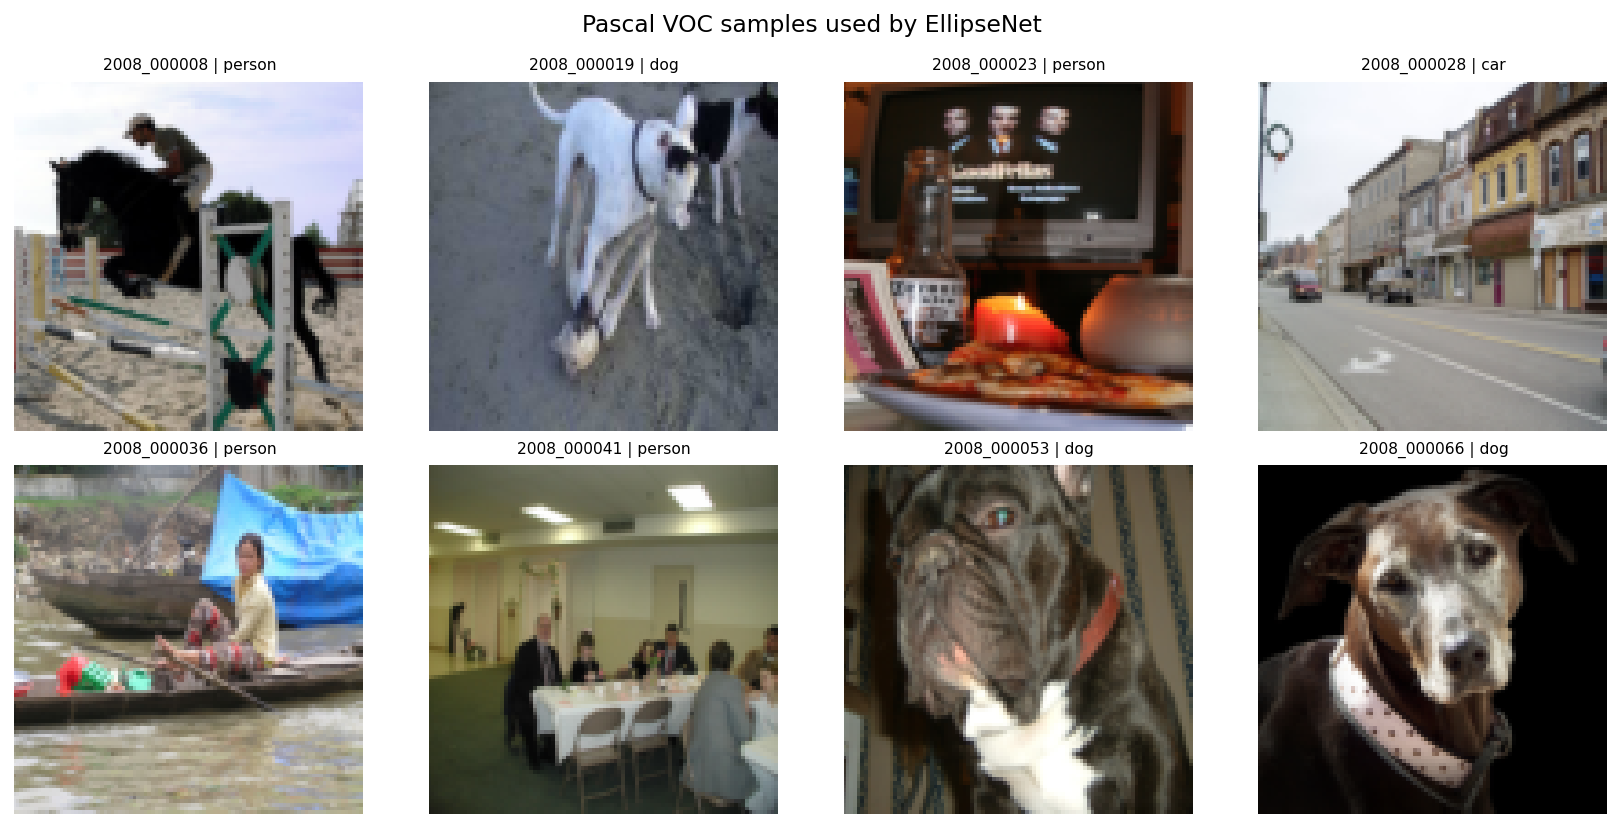

A quick sample grid of the VOC images used for the selected classes: person, car, and dog.


### Rectangle Annotation to Ellipse Target

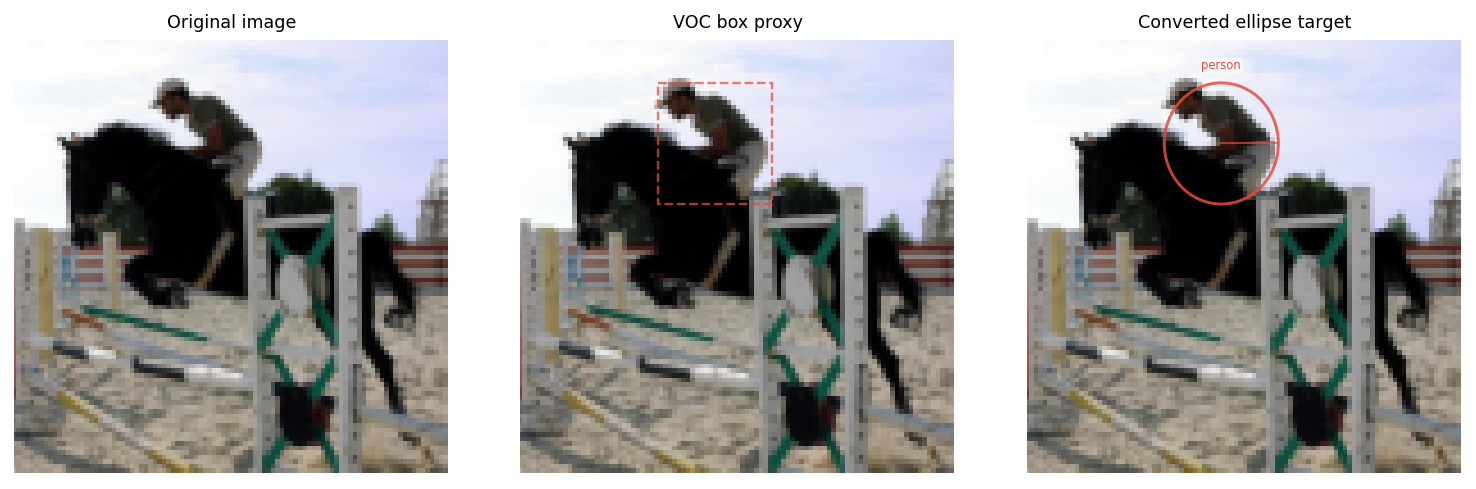

The VOC box proxy is converted into the final ellipse supervision target.


### Ground-Truth Ellipse Overlays

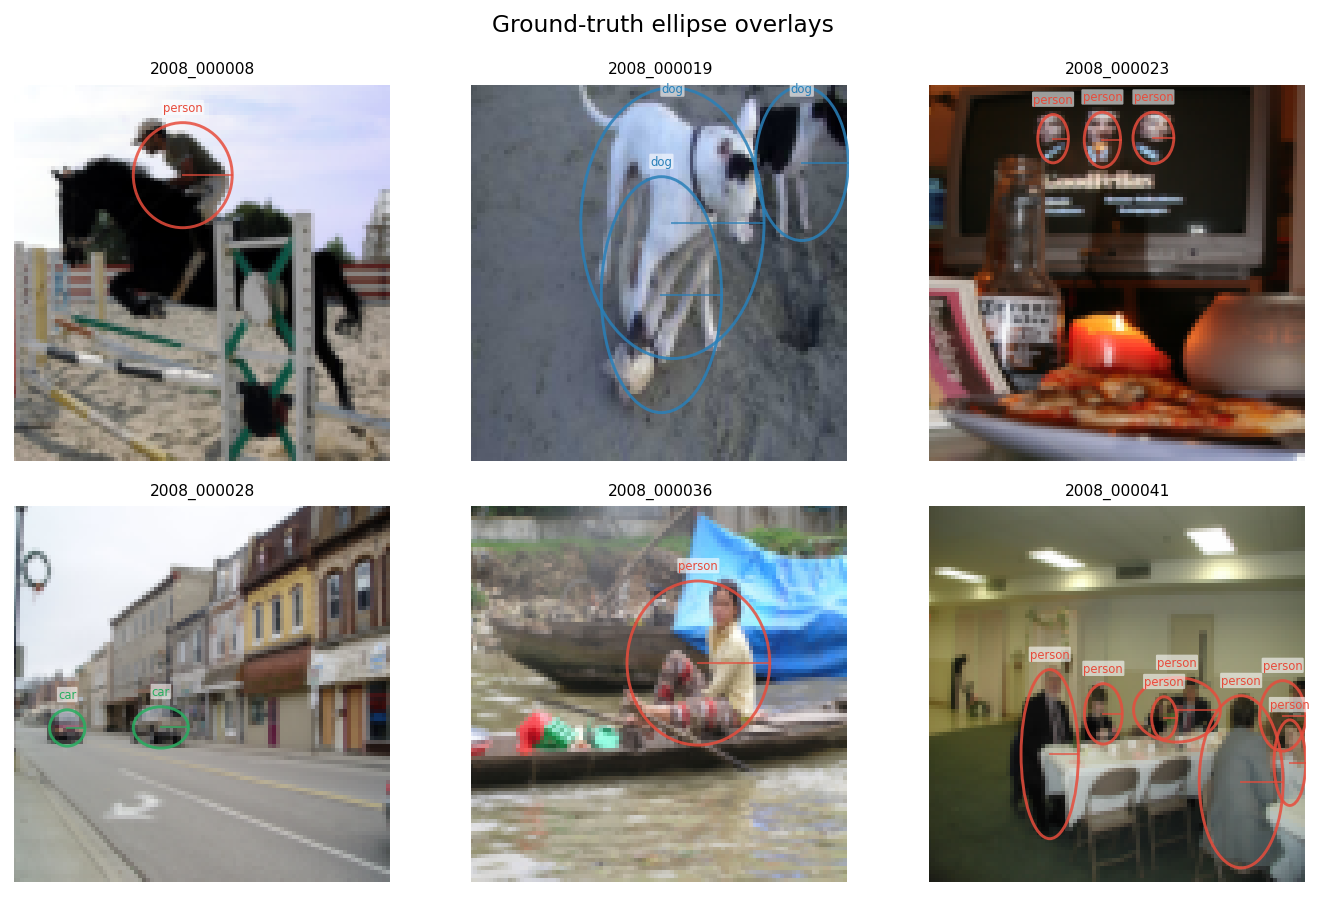

These overlays verify that the converted annotations are visible as ellipse targets on real images.


### Rotation Augmentation With Updated Theta

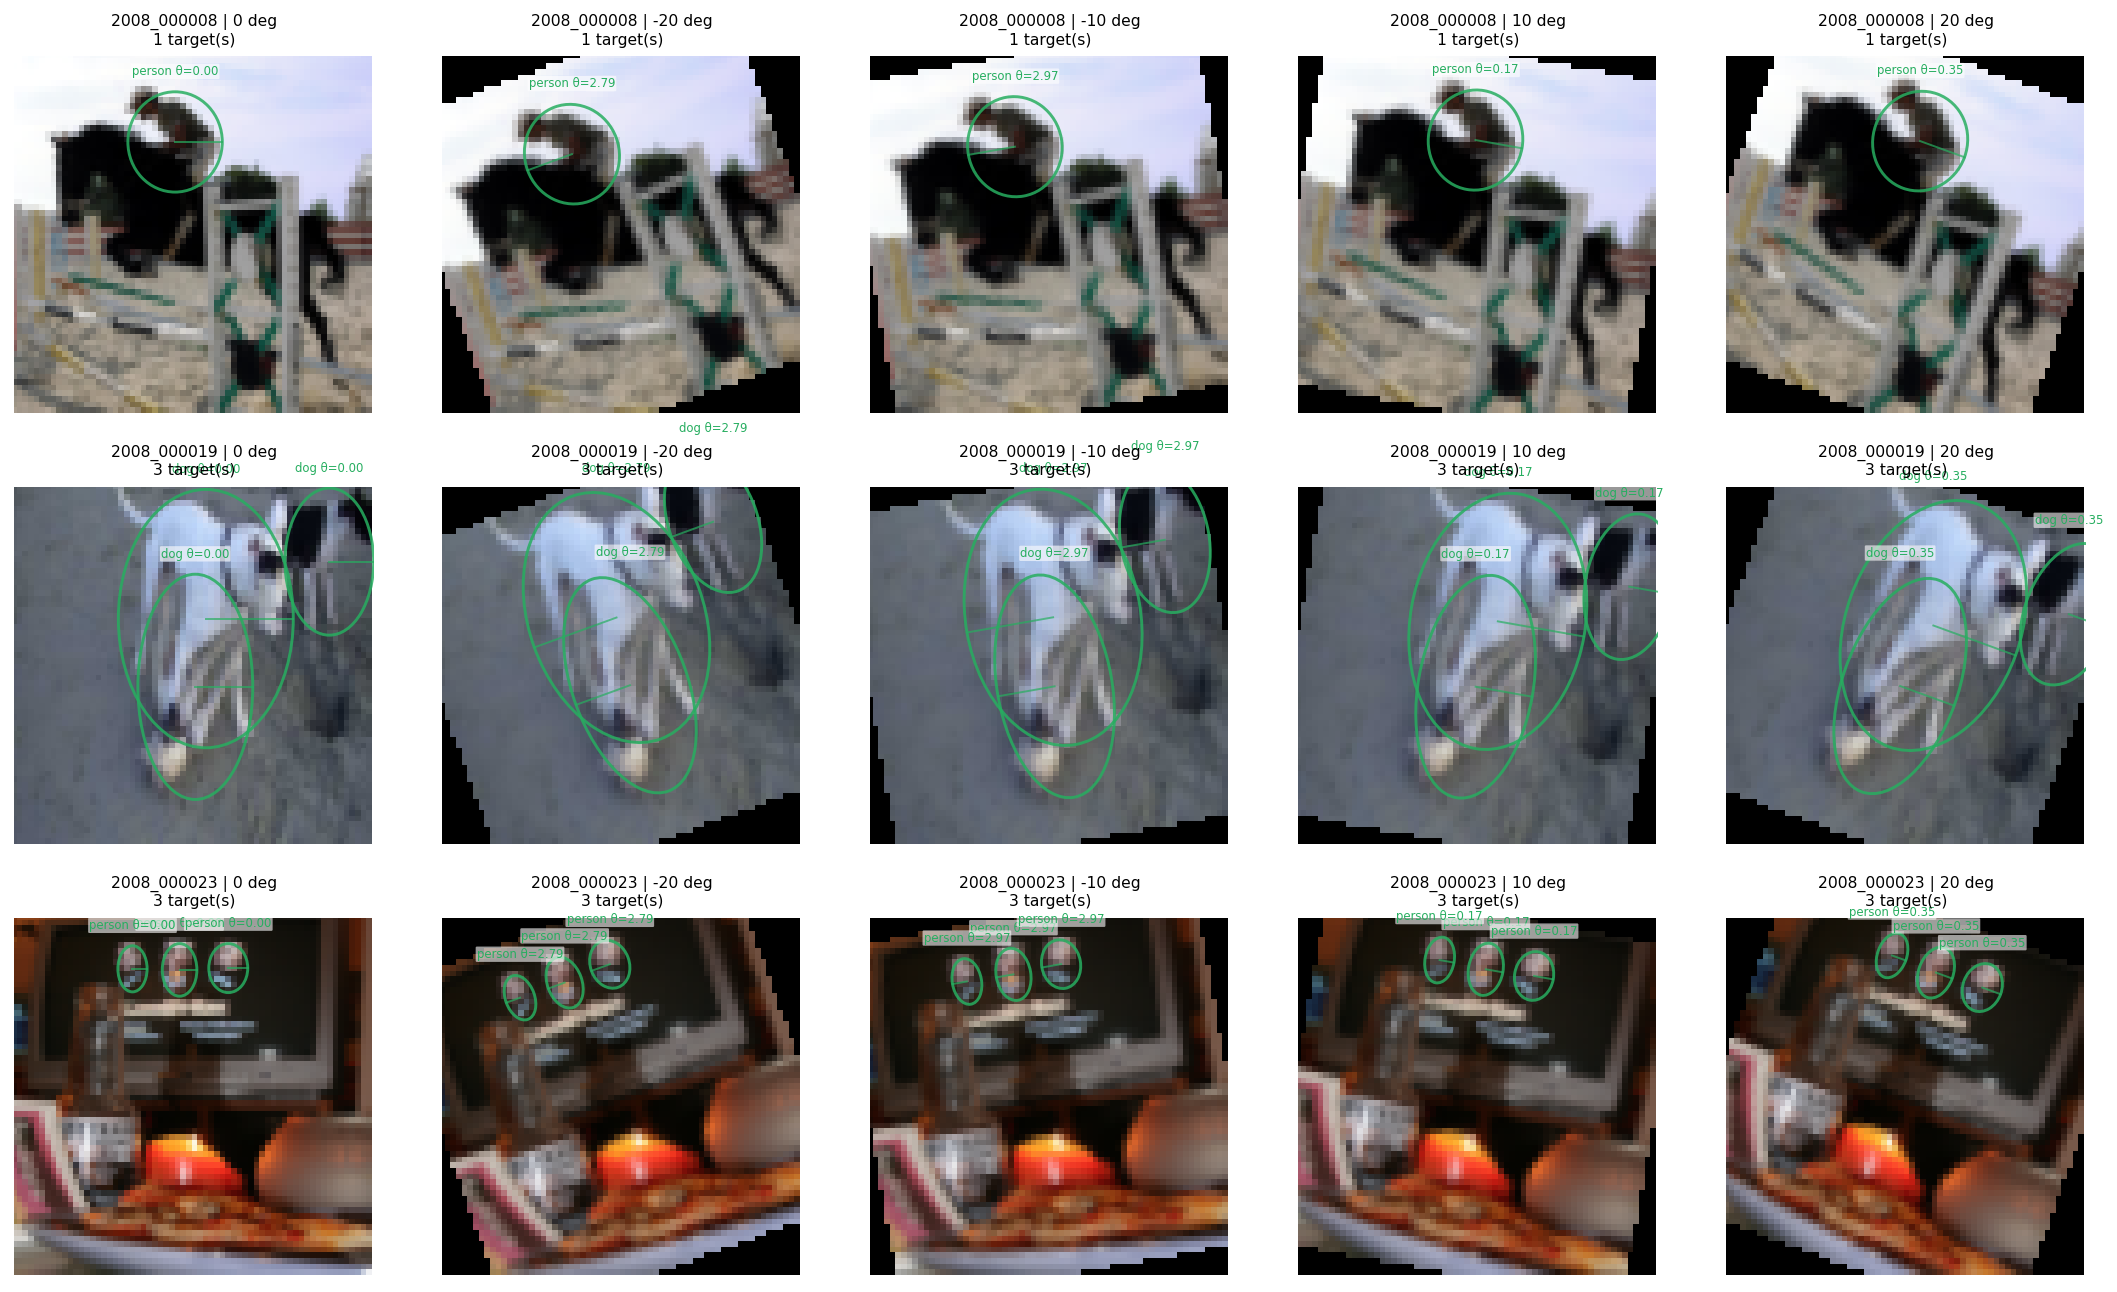

The rotated samples create nonzero orientation targets without collecting a new dataset.


## Step 3 - Network Architectural Adjustments

The CNN is implemented from scratch in NumPy. It satisfies the architecture constraints:

- More than four convolutional layers.
- Nonlinear activations through LeakyReLU.
- Max-pooling layers to downsample spatial dimensions.
- 1x1 pointwise convolutions for cross-channel pooling and dimensionality reduction.
- A detection head that outputs ellipse localization, objectness, and class logits.

For `IMG_SIZE = 64`, three max-pooling operations produce an `8 x 8` output grid. Each cell predicts `B = 2` anchors, and each anchor emits `6 + C` values.


In [ ]:
# NumPy layer library: convolution, pooling, activation, batch norm, dense, dropout.
"""
EllipseNet — Layer Library (NumPy only, no autograd)
Each layer exposes:
    forward(x, training=True)  -> output
    backward(grad_out)         -> grad_in
    params()                   -> list of (param_array, grad_array) tuples
"""

import numpy as np


# ─────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────
def im2col(x, kH, kW, stride=1, pad=0):
    """Convert image patches to columns for efficient convolution."""
    N, C, H, W = x.shape
    x_pad = np.pad(x, ((0,0),(0,0),(pad,pad),(pad,pad)), mode='constant')
    out_H = (H + 2*pad - kH) // stride + 1
    out_W = (W + 2*pad - kW) // stride + 1
    col = np.zeros((N, C, kH, kW, out_H, out_W))
    for r in range(kH):
        r_max = r + stride * out_H
        for c in range(kW):
            c_max = c + stride * out_W
            col[:, :, r, c, :, :] = x_pad[:, :, r:r_max:stride, c:c_max:stride]
    col = col.transpose(0, 4, 5, 1, 2, 3).reshape(N * out_H * out_W, -1)
    return col, out_H, out_W


def col2im(col, x_shape, kH, kW, stride=1, pad=0):
    """Inverse of im2col — accumulate gradients back to image space."""
    N, C, H, W = x_shape
    out_H = (H + 2*pad - kH) // stride + 1
    out_W = (W + 2*pad - kW) // stride + 1
    col = col.reshape(N, out_H, out_W, C, kH, kW).transpose(0, 3, 4, 5, 1, 2)
    x_pad = np.zeros((N, C, H + 2*pad, W + 2*pad))
    for r in range(kH):
        r_max = r + stride * out_H
        for c in range(kW):
            c_max = c + stride * out_W
            x_pad[:, :, r:r_max:stride, c:c_max:stride] += col[:, :, r, c, :, :]
    if pad == 0:
        return x_pad
    return x_pad[:, :, pad:-pad, pad:-pad]


# ─────────────────────────────────────────────
# Conv2D
# ─────────────────────────────────────────────
class Conv2D:
    """
    2-D cross-correlation layer.
    W shape: (out_channels, in_channels, kH, kW)
    """
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, pad=None):
        self.in_ch = in_ch
        self.out_ch = out_ch
        self.k = kernel
        self.stride = stride
        self.pad = kernel // 2 if pad is None else pad
        # He initialisation
        std = np.sqrt(2.0 / (in_ch * kernel * kernel))
        self.W = np.random.randn(out_ch, in_ch, kernel, kernel) * std
        self.b = np.zeros(out_ch)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self._cache = None

    def forward(self, x, training=True):
        N, C, H, W_img = x.shape
        col, oH, oW = im2col(x, self.k, self.k, self.stride, self.pad)
        W_flat = self.W.reshape(self.out_ch, -1)          # (out_ch, C*k*k)
        out = col @ W_flat.T + self.b                      # (N*oH*oW, out_ch)
        out = out.reshape(N, oH, oW, self.out_ch).transpose(0, 3, 1, 2)
        if training:
            self._cache = (x, col, oH, oW)
        return out

    def backward(self, grad_out):
        x, col, oH, oW = self._cache
        N = x.shape[0]
        # grad_out: (N, out_ch, oH, oW)
        g = grad_out.transpose(0, 2, 3, 1).reshape(-1, self.out_ch)  # (N*oH*oW, out_ch)
        self.dW = (g.T @ col).reshape(self.W.shape)
        self.db = g.sum(axis=0)
        W_flat = self.W.reshape(self.out_ch, -1)
        d_col = g @ W_flat                                 # (N*oH*oW, C*k*k)
        grad_in = col2im(d_col, x.shape, self.k, self.k, self.stride, self.pad)
        return grad_in

    def params(self):
        return [(self.W, self.dW), (self.b, self.db)]


# ─────────────────────────────────────────────
# Conv1x1  (pointwise — required by spec)
# ─────────────────────────────────────────────
class Conv1x1(Conv2D):
    """Pointwise convolution — inherits Conv2D with kernel=1, pad=0."""
    def __init__(self, in_ch, out_ch):
        super().__init__(in_ch, out_ch, kernel=1, stride=1, pad=0)


# ─────────────────────────────────────────────
# MaxPool2D
# ─────────────────────────────────────────────
class MaxPool2D:
    def __init__(self, pool=2, stride=2):
        self.pool = pool
        self.stride = stride
        self._cache = None

    def forward(self, x, training=True):
        N, C, H, W = x.shape
        p, s = self.pool, self.stride
        oH = (H - p) // s + 1
        oW = (W - p) // s + 1
        out = np.zeros((N, C, oH, oW))
        mask = np.zeros_like(x, dtype=bool)
        for i in range(oH):
            for j in range(oW):
                patch = x[:, :, i*s:i*s+p, j*s:j*s+p]         # (N,C,p,p)
                mx = patch.max(axis=(2,3), keepdims=True)
                m = (patch == mx)
                # break ties: keep first occurrence
                flat = m.reshape(N, C, -1)
                first = np.zeros_like(flat)
                idx = flat.argmax(axis=2)
                first[np.arange(N)[:,None], np.arange(C)[None,:], idx] = True
                m = first.reshape(N, C, p, p)
                mask[:, :, i*s:i*s+p, j*s:j*s+p] |= m
                out[:, :, i, j] = (patch * m).sum(axis=(2,3))
        if training:
            self._cache = (x.shape, mask, oH, oW)
        return out

    def backward(self, grad_out):
        x_shape, mask, oH, oW = self._cache
        N, C, H, W = x_shape
        p, s = self.pool, self.stride
        grad_in = np.zeros(x_shape)
        for i in range(oH):
            for j in range(oW):
                g = grad_out[:, :, i, j][:, :, None, None]  # broadcast
                grad_in[:, :, i*s:i*s+p, j*s:j*s+p] += g * mask[:, :, i*s:i*s+p, j*s:j*s+p]
        return grad_in

    def params(self):
        return []


# ─────────────────────────────────────────────
# ReLU
# ─────────────────────────────────────────────
class ReLU:
    def __init__(self):
        self._cache = None

    def forward(self, x, training=True):
        if training:
            self._cache = x
        return np.maximum(0, x)

    def backward(self, grad_out):
        return grad_out * (self._cache > 0)

    def params(self):
        return []


# ─────────────────────────────────────────────
# LeakyReLU
# ─────────────────────────────────────────────
class LeakyReLU:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self._cache = None

    def forward(self, x, training=True):
        if training:
            self._cache = x
        return np.where(x > 0, x, self.alpha * x)

    def backward(self, grad_out):
        return grad_out * np.where(self._cache > 0, 1.0, self.alpha)

    def params(self):
        return []


# ─────────────────────────────────────────────
# BatchNorm2D
# ─────────────────────────────────────────────
class BatchNorm2D:
    """
    Batch normalisation over (N, H, W) per channel.
    Running stats used at inference time.
    """
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.gamma = np.ones(num_features)
        self.beta = np.zeros(num_features)
        self.dgamma = np.zeros_like(self.gamma)
        self.dbeta = np.zeros_like(self.beta)
        self.running_mean = np.zeros(num_features)
        self.running_var = np.ones(num_features)
        self._cache = None

    def forward(self, x, training=True):
        # x: (N, C, H, W)
        N, C, H, W = x.shape
        if training:
            mean = x.mean(axis=(0, 2, 3))           # (C,)
            var  = x.var(axis=(0, 2, 3))
            x_norm = (x - mean[None,:,None,None]) / np.sqrt(var[None,:,None,None] + self.eps)
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean
            self.running_var  = (1 - self.momentum) * self.running_var  + self.momentum * var
            self._cache = (x, x_norm, mean, var)
        else:
            x_norm = (x - self.running_mean[None,:,None,None]) / np.sqrt(self.running_var[None,:,None,None] + self.eps)
        return self.gamma[None,:,None,None] * x_norm + self.beta[None,:,None,None]

    def backward(self, grad_out):
        x, x_norm, mean, var = self._cache
        N, C, H, W = x.shape
        m = N * H * W
        self.dgamma = (grad_out * x_norm).sum(axis=(0,2,3))
        self.dbeta  = grad_out.sum(axis=(0,2,3))
        dx_norm = grad_out * self.gamma[None,:,None,None]
        dvar = (dx_norm * (x - mean[None,:,None,None]) * -0.5 *
                (var[None,:,None,None] + self.eps)**(-1.5)).sum(axis=(0,2,3))
        dmean = (dx_norm * -1 / np.sqrt(var[None,:,None,None] + self.eps)).sum(axis=(0,2,3)) \
                + dvar * (-2 * (x - mean[None,:,None,None])).mean(axis=(0,2,3))
        grad_in = (dx_norm / np.sqrt(var[None,:,None,None] + self.eps)
                   + dvar[None,:,None,None] * 2 * (x - mean[None,:,None,None]) / m
                   + dmean[None,:,None,None] / m)
        return grad_in

    def params(self):
        return [(self.gamma, self.dgamma), (self.beta, self.dbeta)]


# ─────────────────────────────────────────────
# Dense (Fully Connected)
# ─────────────────────────────────────────────
class Dense:
    def __init__(self, in_dim, out_dim):
        std = np.sqrt(2.0 / in_dim)
        self.W = np.random.randn(in_dim, out_dim) * std
        self.b = np.zeros(out_dim)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self._cache = None

    def forward(self, x, training=True):
        if training:
            self._cache = x
        return x @ self.W + self.b

    def backward(self, grad_out):
        x = self._cache
        self.dW = x.T @ grad_out
        self.db = grad_out.sum(axis=0)
        return grad_out @ self.W.T

    def params(self):
        return [(self.W, self.dW), (self.b, self.db)]


# ─────────────────────────────────────────────
# Sequential container
# ─────────────────────────────────────────────
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x, training=True):
        for layer in self.layers:
            x = layer.forward(x, training)
        return x

    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad

    def params(self):
        p = []
        for layer in self.layers:
            p.extend(layer.params())
        return p


# ─────────────────────────────────────────────
# Dropout
# ─────────────────────────────────────────────
class Dropout:
    def __init__(self, rate=0.5):
        self.rate = rate
        self._mask = None

    def forward(self, x, training=True):
        if training:
            self._mask = (np.random.rand(*x.shape) > self.rate) / (1 - self.rate)
            return x * self._mask
        return x

    def backward(self, grad_out):
        return grad_out * self._mask

    def params(self):
        return []


In [ ]:
# Custom optimizers and gradient checking.
"""
EllipseNet — Optimizers (from scratch, NumPy only)
"""

import numpy as np


# ─────────────────────────────────────────────
# Adam
# ─────────────────────────────────────────────
class Adam:
    """
    Adam optimizer — Kingma & Ba 2015.
    Maintains per-parameter first and second moment estimates.
    """
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.0):
        """
        params : list of (param_array, grad_array) tuples
        """
        self.params = params
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        self.t = 0
        self.m = [np.zeros_like(p) for p, _ in params]
        self.v = [np.zeros_like(p) for p, _ in params]

    def step(self):
        self.t += 1
        for i, (p, g) in enumerate(self.params):
            if self.weight_decay > 0:
                g = g + self.weight_decay * p
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * g**2
            m_hat = self.m[i] / (1 - self.beta1**self.t)
            v_hat = self.v[i] / (1 - self.beta2**self.t)
            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

    def zero_grad(self):
        for _, g in self.params:
            g[:] = 0.0

    def set_lr(self, lr):
        self.lr = lr


# ─────────────────────────────────────────────
# SGD with momentum
# ─────────────────────────────────────────────
class SGD:
    def __init__(self, params, lr=1e-2, momentum=0.9, weight_decay=0.0):
        self.params = params
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.velocity = [np.zeros_like(p) for p, _ in params]

    def step(self):
        for i, (p, g) in enumerate(self.params):
            if self.weight_decay > 0:
                g = g + self.weight_decay * p
            self.velocity[i] = self.momentum * self.velocity[i] - self.lr * g
            p += self.velocity[i]

    def zero_grad(self):
        for _, g in self.params:
            g[:] = 0.0

    def set_lr(self, lr):
        self.lr = lr


# ─────────────────────────────────────────────
# Learning-rate scheduler helpers
# ─────────────────────────────────────────────
def warmup_cosine_lr(step, warmup_steps, total_steps, base_lr, min_lr=1e-6):
    """Warmup then cosine decay."""
    if step < warmup_steps:
        return base_lr * step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + np.cos(np.pi * progress))


def step_lr(epoch, milestones, base_lr, gamma=0.1):
    """Multiply LR by gamma at each milestone epoch."""
    lr = base_lr
    for m in milestones:
        if epoch >= m:
            lr *= gamma
    return lr


# ─────────────────────────────────────────────
# Gradient checker
# ─────────────────────────────────────────────
def gradient_check(layer, x, grad_out, eps=1e-5, tol=1e-4, n_checks=60):
    """
    Numerical gradient check for any layer.
    Compares analytical gradient (from backward) vs finite-difference estimate
    at n_checks randomly sampled input positions.
    Returns max relative error over sampled positions.
    """
    x = x.copy().astype(np.float64)

    # ── analytical gradient ──────────────────
    _ = layer.forward(x, training=True)
    grad_x_analytical = layer.backward(grad_out)

    # ── numerical gradient (sampled positions) ──
    flat_size = x.size
    sample_idx = np.random.choice(flat_size, size=min(n_checks, flat_size), replace=False)
    x_flat = x.ravel()
    ga_flat = grad_x_analytical.ravel()
    rel_errs = []

    for fi in sample_idx:
        orig = x_flat[fi]
        x_flat[fi] = orig + eps
        fp = layer.forward(x_flat.reshape(x.shape), training=True)
        loss_p = (fp * grad_out).sum()
        x_flat[fi] = orig - eps
        fm = layer.forward(x_flat.reshape(x.shape), training=True)
        loss_m = (fm * grad_out).sum()
        x_flat[fi] = orig
        gn = (loss_p - loss_m) / (2 * eps)
        ga = ga_flat[fi]
        rel_err = abs(ga - gn) / (abs(ga) + abs(gn) + 1e-10)
        rel_errs.append(rel_err)

    max_err = max(rel_errs) if rel_errs else 0.0
    status = "PASS ✓" if max_err < tol else f"FAIL ✗ (tol={tol})"
    print(f"  [{layer.__class__.__name__}] max relative gradient error = {max_err:.2e}  {status}")
    return max_err


In [ ]:
# Ellipse IoU, activation helpers, loss functions, and ellipse NMS.
"""
EllipseNet — Ellipse IoU & Loss Functions (NumPy only)

Key ideas
─────────
• Ellipse-IoU is computed via Monte Carlo sampling: randomly sample points
  inside the union bounding box and test membership in each ellipse.
  This is differentiable w.r.t. ellipse parameters via finite differences.

• The total loss has five terms:
    L = λ_loc  * (1 - EIoU)      — localisation
      + λ_obj  * BCE(obj, 1)     — objectness, responsible cells
      + λ_noobj* BCE(obj, 0)     — objectness, background cells
      + λ_cls  * CE(cls, gt)     — classification
      + λ_theta* angle_loss      — theta stabilisation
"""

import numpy as np


# ─────────────────────────────────────────────
# Ellipse membership test
# ─────────────────────────────────────────────
def point_in_ellipse(px, py, cx, cy, a, b, theta):
    """
    Returns True if point (px, py) lies inside ellipse (cx,cy,a,b,theta).
    Works on numpy arrays; px, py may be arrays.
    Ellipse equation in rotated frame:
        ((x')/a)² + ((y')/b)² ≤ 1
    where x' = (px-cx)cos(θ) + (py-cy)sin(θ)
          y' =-(px-cx)sin(θ) + (py-cy)cos(θ)
    """
    a   = max(a, 1e-6)
    b   = max(b, 1e-6)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    dx = px - cx
    dy = py - cy
    xr = dx * cos_t + dy * sin_t
    yr = -dx * sin_t + dy * cos_t
    return (xr**2 / a**2 + yr**2 / b**2) <= 1.0


def ellipse_iou_mc(e1, e2, n_samples=500):
    """
    Monte Carlo estimate of Intersection-over-Union between two ellipses.

    e1, e2 : (cx, cy, a, b, theta) — normalised coords [0,1]
    Returns scalar IoU in [0, 1].
    """
    cx1, cy1, a1, b1, t1 = e1
    cx2, cy2, a2, b2, t2 = e2

    a1, b1 = max(a1, 1e-6), max(b1, 1e-6)
    a2, b2 = max(a2, 1e-6), max(b2, 1e-6)

    # Axis-aligned bounding box of each ellipse
    def ellipse_aabb(cx, cy, a, b, theta):
        tx = np.sqrt(a**2 * np.cos(theta)**2 + b**2 * np.sin(theta)**2)
        ty = np.sqrt(a**2 * np.sin(theta)**2 + b**2 * np.cos(theta)**2)
        return cx - tx, cy - ty, cx + tx, cy + ty

    x1min, y1min, x1max, y1max = ellipse_aabb(cx1, cy1, a1, b1, t1)
    x2min, y2min, x2max, y2max = ellipse_aabb(cx2, cy2, a2, b2, t2)

    ux_min = min(x1min, x2min)
    uy_min = min(y1min, y2min)
    ux_max = max(x1max, x2max)
    uy_max = max(y1max, y2max)

    if ux_max <= ux_min or uy_max <= uy_min:
        return 0.0

    px = np.random.uniform(ux_min, ux_max, n_samples)
    py = np.random.uniform(uy_min, uy_max, n_samples)

    in1 = point_in_ellipse(px, py, cx1, cy1, a1, b1, t1)
    in2 = point_in_ellipse(px, py, cx2, cy2, a2, b2, t2)

    intersection = np.logical_and(in1, in2).sum()
    union        = np.logical_or (in1, in2).sum()

    if union == 0:
        return 0.0
    return float(intersection) / float(union)


def batch_ellipse_iou(pred_ellipses, gt_ellipses, n_samples=300):
    """
    Compute IoU for matched pairs.
    pred_ellipses, gt_ellipses : (N, 5) arrays
    Returns (N,) IoU values.
    """
    N = pred_ellipses.shape[0]
    ious = np.zeros(N)
    for i in range(N):
        ious[i] = ellipse_iou_mc(pred_ellipses[i], gt_ellipses[i], n_samples)
    return ious


# ─────────────────────────────────────────────
# Angle loss (handles π-periodicity)
# ─────────────────────────────────────────────
def angle_loss(theta_pred, theta_gt):
    """
    Smooth angle loss robust to π-periodicity:
        L = min(|p - g|, π - |p - g|)
    Works on arrays.
    """
    diff = np.abs(theta_pred - theta_gt)
    return np.minimum(diff, np.pi - diff)


# ─────────────────────────────────────────────
# Binary cross-entropy (numerically stable)
# ─────────────────────────────────────────────
def bce(pred, target, eps=1e-7):
    """Element-wise BCE. pred in (0,1)."""
    pred = np.clip(pred, eps, 1 - eps)
    return -(target * np.log(pred) + (1 - target) * np.log(1 - pred))


def bce_grad(pred, target, eps=1e-7):
    """Gradient of BCE w.r.t. pred."""
    pred = np.clip(pred, eps, 1 - eps)
    return -(target / pred) + (1 - target) / (1 - pred)


# ─────────────────────────────────────────────
# Softmax cross-entropy
# ─────────────────────────────────────────────
def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)


def cross_entropy(logits, labels, eps=1e-7):
    """logits: (N, C), labels: (N,) int.  Returns scalar."""
    probs = softmax(logits)
    N = logits.shape[0]
    if N == 0:
        return 0.0
    return -np.log(probs[np.arange(N), labels] + eps).mean()


def cross_entropy_grad(logits, labels):
    """Gradient of softmax-CE w.r.t. logits."""
    probs = softmax(logits)
    N = logits.shape[0]
    if N == 0:
        return np.zeros_like(logits)
    probs[np.arange(N), labels] -= 1
    return probs / N


# ─────────────────────────────────────────────
# Sigmoid & derivative
# ─────────────────────────────────────────────
def sigmoid(x):
    return np.where(x >= 0,
                    1 / (1 + np.exp(-x)),
                    np.exp(x) / (1 + np.exp(x)))


def sigmoid_grad(x):
    s = sigmoid(x)
    return s * (1 - s)


# ─────────────────────────────────────────────
# EllipseNet Loss
# ─────────────────────────────────────────────
class EllipseLoss:
    """
    Computes the combined detection loss and returns (scalar_loss, grad_dict).

    Output tensor expected shape: (N, S, S, B, 6 + C)
    where dim-5 layout is:
        [0]      raw objectness logit
        [1:3]    raw cx, cy offsets (pre-sigmoid)
        [3:5]    raw log_a, log_b offsets
        [5]      raw theta (pre-pi*sigmoid)
        [6:]     raw class logits

    targets : list (len=N) of lists of dicts with keys
        {class_id, cx, cy, a, b, theta}
    """

    def __init__(self, S=8, B=2, C=3, anchors=None,
                 lambda_loc=5.0, lambda_obj=1.0, lambda_noobj=0.5,
                 lambda_cls=1.0, lambda_theta=2.0):
        self.S = S
        self.B = B
        self.C = C
        self.lambda_loc   = lambda_loc
        self.lambda_obj   = lambda_obj
        self.lambda_noobj = lambda_noobj
        self.lambda_cls   = lambda_cls
        self.lambda_theta = lambda_theta

        if anchors is None:
            # default anchor semi-axes (normalised), shape (B, 2)
            self.anchors = np.array([
                [0.10, 0.07],
                [0.20, 0.14],
            ])
        else:
            self.anchors = np.array(anchors)

    # ─── decode raw output → (cx, cy, a, b, theta, conf, cls_probs) ───
    def decode(self, raw, training=True):
        """
        raw : (N, S, S, B, 6+C)
        Returns decoded dict with same leading dims.
        """
        S = self.S
        conf  = sigmoid(raw[..., 0])         # objectness
        # cx, cy: offset from grid cell, in [0,1] within cell
        cx_off = sigmoid(raw[..., 1])
        cy_off = sigmoid(raw[..., 2])
        # absolute centre (normalised to full image)
        grid_x = np.arange(S).reshape(1, 1, S, 1)
        grid_y = np.arange(S).reshape(1, S, 1, 1)
        cx = (cx_off + grid_x) / S
        cy = (cy_off + grid_y) / S
        # semi-axes: exp(raw) * anchor
        a = np.exp(raw[..., 3]) * self.anchors[None, None, None, :, 0]
        b = np.exp(raw[..., 4]) * self.anchors[None, None, None, :, 1]
        # theta in [0, pi)
        theta = np.pi * sigmoid(raw[..., 5])
        cls_logits = raw[..., 6:]
        return conf, cx, cy, a, b, theta, cls_logits

    # ─── build target tensors ─────────────────────────────────────────
    def _build_targets(self, targets, N):
        """
        Assign each ground-truth ellipse to the best-matching anchor/cell.
        Returns boolean masks and target arrays (all numpy).
        """
        S, B, C = self.S, self.B, self.C
        obj_mask   = np.zeros((N, S, S, B), dtype=bool)
        noobj_mask = np.ones ((N, S, S, B), dtype=bool)
        tgt_cx    = np.zeros((N, S, S, B))
        tgt_cy    = np.zeros((N, S, S, B))
        tgt_a     = np.zeros((N, S, S, B))
        tgt_b     = np.zeros((N, S, S, B))
        tgt_theta = np.zeros((N, S, S, B))
        tgt_cls   = np.zeros((N, S, S, B), dtype=int)

        for ni, img_targets in enumerate(targets):
            for gt in img_targets:
                cx, cy = gt['cx'], gt['cy']
                a,  b  = gt['a'],  gt['b']
                theta  = gt['theta']
                cls    = int(gt['class_id'])

                # which grid cell
                gi = min(int(cx * S), S - 1)
                gj = min(int(cy * S), S - 1)

                # which anchor best matches by aspect-ratio IoU (axis-aligned)
                best_iou = -1
                best_b   = 0
                for bi in range(B):
                    an_a, an_b = self.anchors[bi]
                    # Jaccard between two axis-aligned ellipses centred at origin
                    inter_a = min(a, an_a)
                    inter_b = min(b, an_b)
                    inter   = np.pi * inter_a * inter_b
                    union   = np.pi * (a * b + an_a * an_b - inter_a * inter_b)
                    iou     = inter / max(union, 1e-9)
                    if iou > best_iou:
                        best_iou = iou
                        best_b   = bi

                obj_mask  [ni, gj, gi, best_b] = True
                noobj_mask[ni, gj, gi, best_b] = False
                # targets are offsets / log-scale
                tgt_cx   [ni, gj, gi, best_b] = cx * S - gi
                tgt_cy   [ni, gj, gi, best_b] = cy * S - gj
                tgt_a    [ni, gj, gi, best_b] = np.log(max(a  / self.anchors[best_b, 0], 1e-6))
                tgt_b    [ni, gj, gi, best_b] = np.log(max(b  / self.anchors[best_b, 1], 1e-6))
                tgt_theta[ni, gj, gi, best_b] = theta
                tgt_cls  [ni, gj, gi, best_b] = cls

        return (obj_mask, noobj_mask,
                tgt_cx, tgt_cy, tgt_a, tgt_b, tgt_theta, tgt_cls)

    # ─── main loss compute ────────────────────────────────────────────
    def compute(self, raw, targets):
        """
        raw     : (N, S, S, B, 6+C) — raw network outputs
        targets : list of N lists of gt dicts
        Returns (loss_scalar, grad_raw)
        """
        N, S, _, B, outd = raw.shape
        expected_outd = 6 + self.C
        if S != self.S or raw.shape[2] != self.S or B != self.B or outd != expected_outd:
            raise ValueError(
                f"Loss expected raw shape (N,{self.S},{self.S},{self.B},{expected_outd}), "
                f"got {raw.shape}."
            )
        grad_raw = np.zeros_like(raw)

        (obj_mask, noobj_mask,
         tgt_cx, tgt_cy, tgt_a, tgt_b, tgt_theta, tgt_cls) = self._build_targets(targets, N)

        # ── decode predictions ────────────────────────────────────────
        conf_raw  = raw[..., 0]
        cx_raw    = raw[..., 1]
        cy_raw    = raw[..., 2]
        a_raw     = raw[..., 3]
        b_raw     = raw[..., 4]
        theta_raw = raw[..., 5]

        conf      = sigmoid(conf_raw)
        cx_pred   = sigmoid(cx_raw)
        cy_pred   = sigmoid(cy_raw)
        theta_pred = np.pi * sigmoid(theta_raw)

        # ── objectness loss ───────────────────────────────────────────
        loss_obj   = bce(conf[obj_mask],   np.ones (obj_mask.sum())).mean()   if obj_mask.any()   else 0.0
        loss_noobj = bce(conf[noobj_mask], np.zeros(noobj_mask.sum())).mean() if noobj_mask.any() else 0.0

        g_conf_obj = np.zeros_like(conf)
        g_conf_noobj = np.zeros_like(conf)
        if obj_mask.any():
            g_conf_obj[obj_mask] = bce_grad(conf[obj_mask], np.ones(obj_mask.sum())) / max(obj_mask.sum(), 1)
        if noobj_mask.any():
            g_conf_noobj[noobj_mask] = bce_grad(conf[noobj_mask], np.zeros(noobj_mask.sum())) / max(noobj_mask.sum(), 1)
        g_conf = self.lambda_obj * g_conf_obj + self.lambda_noobj * g_conf_noobj
        grad_raw[..., 0] = g_conf * sigmoid_grad(conf_raw)

        n_obj = obj_mask.sum()
        if n_obj == 0:
            total_loss = (self.lambda_obj * loss_obj + self.lambda_noobj * loss_noobj)
            loss_dict = dict(
                total=total_loss, loc=0.0,
                obj=loss_obj, noobj=loss_noobj,
                cls=0.0, theta=0.0
            )
            return total_loss, grad_raw, loss_dict

        # ── coordinate losses (responsible anchors only) ───────────────
        # cx, cy: MSE(sigmoid(pred), target)
        cx_err = cx_pred[obj_mask] - tgt_cx[obj_mask]
        cy_err = cy_pred[obj_mask] - tgt_cy[obj_mask]
        loss_cx = (cx_err**2).mean()
        loss_cy = (cy_err**2).mean()

        g_cx_raw = np.zeros_like(cx_raw)
        g_cy_raw = np.zeros_like(cy_raw)
        g_cx_raw[obj_mask] = 2 * cx_err / n_obj * sigmoid_grad(cx_raw[obj_mask])
        g_cy_raw[obj_mask] = 2 * cy_err / n_obj * sigmoid_grad(cy_raw[obj_mask])
        grad_raw[..., 1] = g_cx_raw
        grad_raw[..., 2] = g_cy_raw

        # a, b: MSE in log-space
        a_err = a_raw[obj_mask] - tgt_a[obj_mask]
        b_err = b_raw[obj_mask] - tgt_b[obj_mask]
        loss_ab = ((a_err**2).mean() + (b_err**2).mean()) * 0.5

        g_a = np.zeros_like(a_raw); g_a[obj_mask] = 2 * a_err / n_obj
        g_b = np.zeros_like(b_raw); g_b[obj_mask] = 2 * b_err / n_obj
        grad_raw[..., 3] = g_a
        grad_raw[..., 4] = g_b

        loss_loc = loss_cx + loss_cy + loss_ab

        # ── theta loss ────────────────────────────────────────────────
        al = angle_loss(theta_pred[obj_mask], tgt_theta[obj_mask])
        loss_theta = al.mean()
        # gradient of min(|diff|, π-|diff|) w.r.t. theta_pred
        diff = theta_pred[obj_mask] - tgt_theta[obj_mask]
        sign = np.sign(diff)
        use_direct = np.abs(diff) <= (np.pi - np.abs(diff))
        dangle_dtheta_pred = np.where(use_direct, sign, -sign)
        g_theta_raw = np.zeros_like(theta_raw)
        g_theta_raw[obj_mask] = (dangle_dtheta_pred / n_obj) * np.pi * sigmoid_grad(theta_raw[obj_mask])
        grad_raw[..., 5] = g_theta_raw

        # ── classification loss ───────────────────────────────────────
        cls_logits = raw[..., 6:]                         # (N,S,S,B,C)
        cls_pred   = cls_logits[obj_mask]                 # (n_obj, C)
        cls_target = tgt_cls[obj_mask]                    # (n_obj,)
        loss_cls   = cross_entropy(cls_pred, cls_target)
        g_cls      = np.zeros_like(cls_logits)
        g_cls[obj_mask] = cross_entropy_grad(cls_pred, cls_target)
        grad_raw[..., 6:] = g_cls

        # ── total loss ────────────────────────────────────────────────
        total_loss = (self.lambda_loc   * loss_loc
                    + self.lambda_obj   * loss_obj
                    + self.lambda_noobj * loss_noobj
                    + self.lambda_cls   * loss_cls
                    + self.lambda_theta * loss_theta)

        # Scale each term by its own loss weight.
        grad_raw[..., 1:5] *= self.lambda_loc
        grad_raw[..., 5] *= self.lambda_theta
        grad_raw[..., 6:] *= self.lambda_cls

        loss_dict = dict(
            total=total_loss, loc=loss_loc,
            obj=loss_obj, noobj=loss_noobj,
            cls=loss_cls, theta=loss_theta
        )
        return total_loss, grad_raw, loss_dict


# ─────────────────────────────────────────────
# NMS (ellipse-IoU based)
# ─────────────────────────────────────────────
def ellipse_nms(boxes, scores, iou_thresh=0.4, n_samples=200):
    """
    Non-maximum suppression for ellipse detections.
    boxes  : (N, 5) — cx, cy, a, b, theta
    scores : (N,)
    Returns keep indices.
    """
    order = scores.argsort()[::-1]
    keep  = []
    while len(order):
        i = order[0]
        keep.append(i)
        if len(order) == 1:
            break
        rest = order[1:]
        ious = np.array([ellipse_iou_mc(boxes[i], boxes[j], n_samples) for j in rest])
        order = rest[ious < iou_thresh]
    return keep


In [ ]:
# EllipseNet CNN architecture and inference decoding.
"""
EllipseNet — Full CNN Architecture (NumPy only, no autograd)

Architecture:
    Input (N, 3, H, W)
    ├─ ConvBlock(3→16,  3×3) + BN + LeakyReLU                [Layer 1]
    ├─ ConvBlock(16→32, 3×3) + BN + LeakyReLU + MaxPool2     [Layer 2]
    ├─ Conv1×1(32→32)  + LeakyReLU              ← spec req   [Layer 3]
    ├─ ConvBlock(32→64, 3×3) + BN + LeakyReLU + MaxPool2     [Layer 4]
    ├─ ConvBlock(64→128,3×3) + BN + LeakyReLU                [Layer 5]
    ├─ Conv1×1(128→64) + LeakyReLU              ← dim reduce [Layer 6]
    └─ Conv1×1(64→ B*(6+C))  ← detection head               [Layer 7]

Output shape: (N, B*(6+C), S, S) → reshaped to (N, S, S, B, 6+C)
Output per anchor: [conf_raw, cx_raw, cy_raw, log_a, log_b, theta_raw, cls_1,...,cls_C]
"""

import numpy as np


class ConvBNLeaky:
    """Conv2D + BatchNorm2D + LeakyReLU — the standard YOLO block."""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, pad=None):
        self.conv = Conv2D(in_ch, out_ch, kernel, stride, pad)
        self.bn   = BatchNorm2D(out_ch)
        self.act  = LeakyReLU(0.1)

    def forward(self, x, training=True):
        x = self.conv.forward(x, training)
        x = self.bn.forward(x, training)
        x = self.act.forward(x, training)
        return x

    def backward(self, grad):
        grad = self.act.backward(grad)
        grad = self.bn.backward(grad)
        grad = self.conv.backward(grad)
        return grad

    def params(self):
        return self.conv.params() + self.bn.params()


class Conv1x1BNLeaky:
    """Pointwise conv + BatchNorm + LeakyReLU."""
    def __init__(self, in_ch, out_ch):
        self.conv = Conv1x1(in_ch, out_ch)
        self.bn   = BatchNorm2D(out_ch)
        self.act  = LeakyReLU(0.1)

    def forward(self, x, training=True):
        x = self.conv.forward(x, training)
        x = self.bn.forward(x, training)
        x = self.act.forward(x, training)
        return x

    def backward(self, grad):
        grad = self.act.backward(grad)
        grad = self.bn.backward(grad)
        grad = self.conv.backward(grad)
        return grad

    def params(self):
        return self.conv.params() + self.bn.params()


class EllipseNet:
    """
    Full EllipseNet detector.

    Parameters
    ──────────
    img_size  : input spatial size (assumed square after preprocessing)
    S         : grid size (output feature map will be S×S)
    B         : anchors per cell
    C         : number of classes
    anchors   : (B, 2) array of anchor (semi_a, semi_b) in normalised coords
    """

    def __init__(self, img_size=64, S=8, B=2, C=3, anchors=None):
        self.img_size = img_size
        self.S = S
        self.B = B
        self.C = C
        self.out_ch = B * (6 + C)   # output channels

        if anchors is None:
            self.anchors = np.array([[0.10, 0.07], [0.20, 0.14]])
        else:
            self.anchors = np.array(anchors)

        # ── Build layers ──────────────────────────────────────────────
        # 4+ Conv layers required by spec; we have 5 Conv2D + 2 Conv1x1
        self.block1 = ConvBNLeaky(3,   16,  3)        # Layer 1
        self.pool1  = MaxPool2D(2, 2)
        self.block2 = ConvBNLeaky(16,  32,  3)        # Layer 2
        self.pool2  = MaxPool2D(2, 2)
        self.pw1    = Conv1x1BNLeaky(32,  32)         # Layer 3  ← 1×1 spec
        self.block3 = ConvBNLeaky(32,  64,  3)        # Layer 4
        self.pool3  = MaxPool2D(2, 2)
        self.block4 = ConvBNLeaky(64,  128, 3)        # Layer 5
        self.pw2    = Conv1x1BNLeaky(128, 64)         # Layer 6  ← 1×1 spec
        # Detection head: raw logits, no activation here (applied in loss)
        self.head   = Conv1x1(64, self.out_ch)        # Layer 7

        self._all_blocks = [
            self.block1, self.pool1,
            self.block2, self.pool2,
            self.pw1,
            self.block3, self.pool3,
            self.block4,
            self.pw2,
            self.head,
        ]

    # ─── forward ──────────────────────────────────────────────────────
    def forward(self, x, training=True):
        """
        x : (N, 3, H, W)
        Returns raw output (N, S, S, B, 6+C)
        """
        x = self.block1.forward(x, training)
        x = self.pool1.forward(x, training)
        x = self.block2.forward(x, training)
        x = self.pool2.forward(x, training)
        x = self.pw1.forward(x, training)
        x = self.block3.forward(x, training)
        x = self.pool3.forward(x, training)
        x = self.block4.forward(x, training)
        x = self.pw2.forward(x, training)
        x = self.head.forward(x, training)
        # x: (N, out_ch, S, S) → (N, S, S, B, 6+C)
        N, _, H, W = x.shape
        if H != self.S or W != self.S:
            raise ValueError(
                f"Model output grid is {H}x{W}, but S={self.S}. "
                f"For this architecture use S=img_size/8; e.g. img_size=64 -> S=8."
            )
        x = x.transpose(0, 2, 3, 1)          # (N, S, S, out_ch)
        x = x.reshape(N, H, W, self.B, 6 + self.C)
        return x

    # ─── backward ─────────────────────────────────────────────────────
    def backward(self, grad_out):
        """
        grad_out : (N, S, S, B, 6+C)
        """
        N, H, W, B_, out = grad_out.shape
        # reshape back to (N, out_ch, S, S)
        grad = grad_out.reshape(N, H, W, self.out_ch).transpose(0, 3, 1, 2)
        grad = self.head.backward(grad)
        grad = self.pw2.backward(grad)
        grad = self.block4.backward(grad)
        grad = self.pool3.backward(grad)
        grad = self.block3.backward(grad)
        grad = self.pw1.backward(grad)
        grad = self.pool2.backward(grad)
        grad = self.block2.backward(grad)
        grad = self.pool1.backward(grad)
        grad = self.block1.backward(grad)
        return grad

    # ─── parameter list ───────────────────────────────────────────────
    def params(self):
        p = []
        for blk in self._all_blocks:
            if hasattr(blk, 'params'):
                p.extend(blk.params())
        return p

    # ─── inference: decode + NMS ──────────────────────────────────────
    def predict(self, x, conf_thresh=0.3, nms_thresh=0.4, n_samples=200):
        """
        Run full inference on a batch.
        Returns list (len=N) of dicts with 'boxes', 'scores', 'classes'.
        """
        raw = self.forward(x, training=False)
        N   = x.shape[0]
        results = []
        S = self.S

        grid_x = np.arange(S).reshape(1, S, 1)     # (1,S,1)
        grid_y = np.arange(S).reshape(S, 1, 1)     # (S,1,1)

        for ni in range(N):
            r = raw[ni]                             # (S, S, B, 6+C)
            conf   = sigmoid(r[..., 0])             # (S, S, B)
            cx     = (sigmoid(r[..., 1]) + grid_x) / S
            cy     = (sigmoid(r[..., 2]) + grid_y) / S
            a      = np.exp(r[..., 3]) * self.anchors[:, 0]
            b      = np.exp(r[..., 4]) * self.anchors[:, 1]
            theta  = np.pi * sigmoid(r[..., 5])
            cls_p  = softmax(r[..., 6:])            # (S, S, B, C)
            cls_id = cls_p.argmax(axis=-1)          # (S, S, B)
            cls_sc = cls_p.max(axis=-1)             # (S, S, B)

            score = conf * cls_sc                   # (S, S, B)
            mask  = score > conf_thresh

            if not mask.any():
                results.append({'boxes': np.zeros((0,5)), 'scores': np.zeros(0), 'classes': np.zeros(0,dtype=int)})
                continue

            boxes   = np.stack([cx[mask], cy[mask], a[mask], b[mask], theta[mask]], axis=1)
            scores  = score[mask]
            classes = cls_id[mask]

            keep = ellipse_nms(boxes, scores, nms_thresh, n_samples)
            results.append({
                'boxes':   boxes[keep],
                'scores':  scores[keep],
                'classes': classes[keep],
            })
        return results

    # ─── save / load weights ──────────────────────────────────────────
    def save(self, path):
        """Save all parameters as a .npz archive."""
        arrays = {}
        for i, (p, _) in enumerate(self.params()):
            arrays[f'param_{i}'] = p
        np.savez(path, **arrays)
        print(f"Model saved → {path}")

    def load(self, path):
        """Load parameters from .npz archive."""
        data = np.load(path)
        params = self.params()
        for i, (p, _) in enumerate(params):
            key = f'param_{i}'
            if key in data:
                p[:] = data[key]
        print(f"Model loaded ← {path}")


### Ellipse Anchor Grid

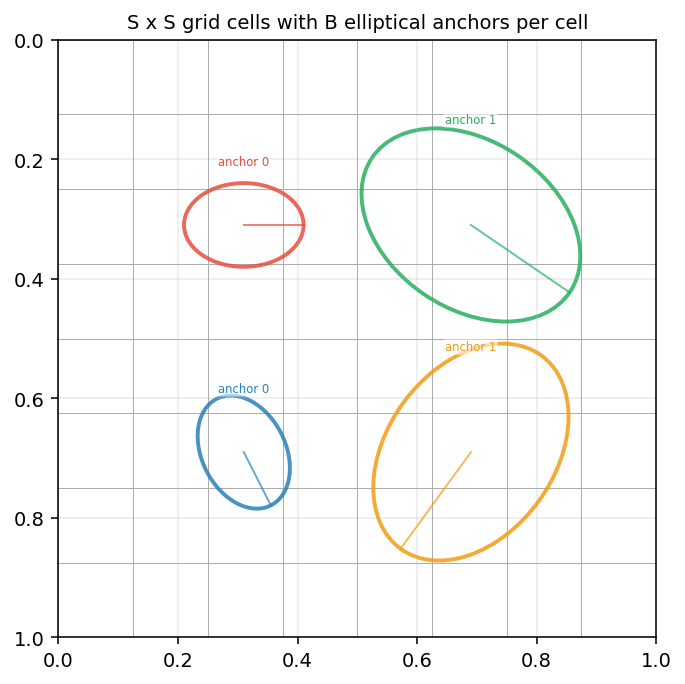

The output layer predicts multiple oriented ellipse anchors per grid cell.


In [ ]:

model = EllipseNet(img_size=IMG_SIZE, S=S, B=B, C=C)
loss_fn = EllipseLoss(S=S, B=B, C=C)

x = np.random.randn(2, 3, IMG_SIZE, IMG_SIZE).astype(np.float32)
y = model.forward(x, training=True)
print('Input shape:', x.shape)
print('Output shape:', y.shape)
print('Expected:', (2, S, S, B, 6 + C))
print('Parameter tensors:', len(model.params()))
print('Total scalar parameters:', sum(p.size for p, _ in model.params()))


## Manual Backpropagation

Every layer implements its own backward pass. The convolution layer uses `im2col` so convolution can be expressed as matrix multiplication. During backpropagation, gradients are computed for filters, biases, and inputs, then passed to the previous layer.

No automated differentiation is used. The optimizer receives explicit `(parameter, gradient)` arrays and updates them directly.


In [ ]:

# Small gradient check for one representative convolution layer.
np.random.seed(0)
small_x = np.random.randn(1, 2, 5, 5)
conv = Conv2D(2, 3, kernel=3)
out = conv.forward(small_x, training=True)
grad_out = np.random.randn(*out.shape)
conv_err = gradient_check(conv, small_x, grad_out, n_checks=20)
print('Conv2D gradient-check max relative error:', conv_err)


## Step 4 - Ellipse IoU and Loss Integration

Exact ellipse intersection is non-trivial, so this implementation estimates ellipse-IoU with Monte Carlo sampling:

1. Build the union bounding region for two ellipses.
2. Sample points inside that region.
3. Count sampled points inside ellipse 1, ellipse 2, both, or either.
4. Estimate `IoU = intersection / union`.

The loss combines localization, objectness, no-objectness, class prediction, and theta stabilization:

`L = lambda_loc * L_loc + lambda_obj * L_obj + lambda_noobj * L_noobj + lambda_cls * L_cls + lambda_theta * L_theta`

The angle term uses `min(|pred - gt|, pi - |pred - gt|)` to respect ellipse orientation periodicity.


### Monte Carlo Ellipse IoU

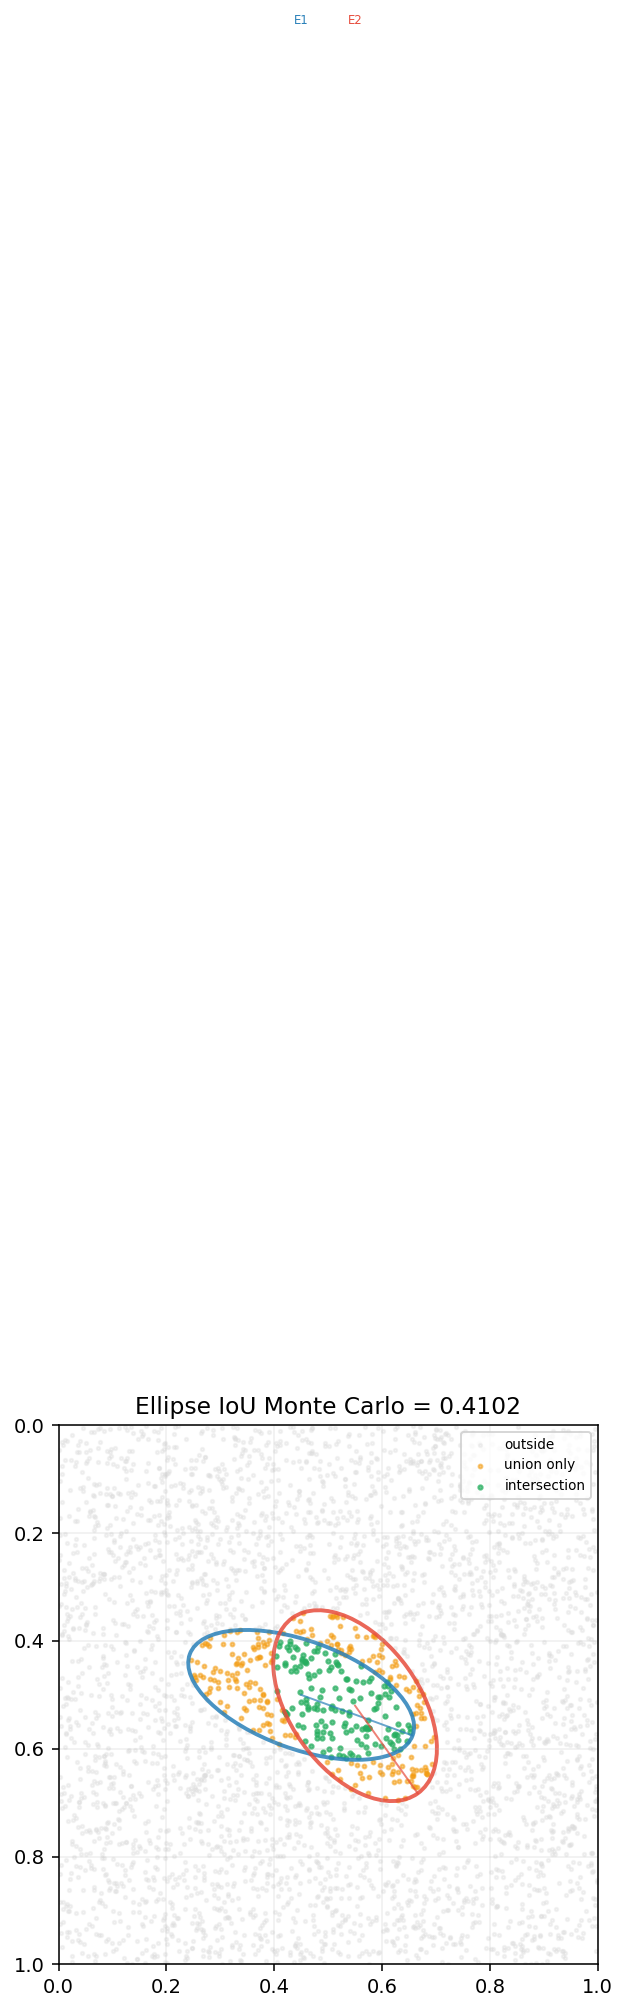

Green points are the estimated intersection; orange points are union-only samples.


In [ ]:

# Precomputed examples, also reproducible with ellipse_iou_mc(...).
iou_examples = {
    "same_ellipse": 1.0,
    "shifted": 0.516807738814994,
    "rotated": 0.34239350912778904
}
iou_examples


In [ ]:

raw = model.forward(np.random.randn(2, 3, IMG_SIZE, IMG_SIZE), training=True)
targets = [train_ds[0][1], train_ds[1][1]]
loss, grad_raw, loss_parts = loss_fn.compute(raw, targets)
print('Loss:', loss)
print('Gradient shape:', grad_raw.shape)
print('Loss components:', loss_parts)


## Step 5 - Training and Iterative Refinement

The default notebook does not retrain automatically. It loads saved training history so the graphs are visible immediately. To retrain, set `RUN_TRAINING = True` in the next training cell.

Training setup:

- Optimizer: custom Adam.
- Learning rate: `1e-4`.
- Schedule: warmup followed by cosine decay.
- Batch size: `4`.
- Checkpointing: save best validation loss.
- Early stopping: stop after no validation improvement.

Because the CNN and backpropagation are from scratch in NumPy, the included training run is intentionally CPU-friendly and demonstrates the full pipeline rather than trying to match production YOLO performance.


In [ ]:
# Training loop.
"""
EllipseNet — Training Loop
"""

import numpy as np
import os
import json
import time


def train_one_epoch(model, loss_fn, optimizer, dataset, batch_size=8,
                    shuffle=True, clip_grad=5.0):
    """
    Runs one training epoch.
    Returns dict of mean losses.
    """
    indices = np.arange(len(dataset))
    if shuffle:
        np.random.shuffle(indices)

    n_batches = max(1, len(indices) // batch_size)
    epoch_losses = {k: 0.0 for k in ['total','loc','obj','noobj','cls','theta']}

    for step in range(n_batches):
        batch_idx = indices[step * batch_size:(step + 1) * batch_size]
        batch = [dataset[i] for i in batch_idx]

        imgs    = np.stack([b[0] for b in batch], axis=0)   # (B,3,H,W)
        targets = [b[1] for b in batch]

        # ── forward ──────────────────────────────────────────────────
        raw  = model.forward(imgs, training=True)
        loss, grad_raw, loss_dict = loss_fn.compute(raw, targets)

        # ── gradient clipping ─────────────────────────────────────────
        grad_norm = np.sqrt((grad_raw**2).sum())
        if grad_norm > clip_grad:
            grad_raw = grad_raw * (clip_grad / (grad_norm + 1e-8))

        # ── backward ──────────────────────────────────────────────────
        optimizer.zero_grad()
        model.backward(grad_raw)
        optimizer.step()

        for k in epoch_losses:
            epoch_losses[k] += loss_dict.get(k, 0.0)

    for k in epoch_losses:
        epoch_losses[k] /= n_batches

    return epoch_losses


def validate(model, loss_fn, dataset, batch_size=8):
    """Run validation without weight updates."""
    indices = np.arange(len(dataset))
    n_batches = max(1, len(indices) // batch_size)
    val_losses = {k: 0.0 for k in ['total','loc','obj','noobj','cls','theta']}

    for step in range(n_batches):
        batch_idx = indices[step * batch_size:(step + 1) * batch_size]
        batch = [dataset[i] for i in batch_idx]
        imgs    = np.stack([b[0] for b in batch], axis=0)
        targets = [b[1] for b in batch]
        raw  = model.forward(imgs, training=False)
        _, _, loss_dict = loss_fn.compute(raw, targets)
        for k in val_losses:
            val_losses[k] += loss_dict.get(k, 0.0)

    for k in val_losses:
        val_losses[k] /= n_batches
    return val_losses


def train(model, loss_fn, train_dataset, val_dataset=None,
          epochs=30, batch_size=8, lr=1e-3,
          checkpoint_dir='checkpoints', log_path='outputs/train_log.json',
          patience=10, warmup_epochs=3):
    """
    Full training loop with:
    - Adam optimiser (from scratch)
    - LR warmup then cosine decay
    - Loss curve logging
    - Early stopping
    - Checkpoint saving (best val loss)
    """
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(os.path.dirname(log_path) or '.', exist_ok=True)

    optimizer  = Adam(model.params(), lr=lr, weight_decay=1e-4)
    total_steps = epochs * max(1, len(train_dataset) // batch_size)
    step        = 0

    history = []
    best_val_loss = float('inf')
    epochs_no_improve = 0

    print(f"{'Epoch':>6} {'Train':>9} {'Val':>9} {'loc':>7} {'obj':>7} "
          f"{'noobj':>7} {'cls':>7} {'θ':>7}  {'LR':>9}  {'Time':>6}")
    print("─" * 85)

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # ── learning rate schedule ────────────────────────────────────
        warmup_steps = warmup_epochs * max(1, len(train_dataset) // batch_size)
        new_lr = warmup_cosine_lr(step, warmup_steps, total_steps, lr)
        optimizer.set_lr(new_lr)

        # ── train ─────────────────────────────────────────────────────
        tr = train_one_epoch(model, loss_fn, optimizer, train_dataset, batch_size)
        step += max(1, len(train_dataset) // batch_size)

        # ── validate ──────────────────────────────────────────────────
        vl = None
        if val_dataset is not None:
            vl = validate(model, loss_fn, val_dataset, batch_size)
            val_total = vl['total']
        else:
            val_total = tr['total']

        elapsed = time.time() - t0
        val_str = f"{val_total:9.4f}" if vl else "       -"
        print(f"{epoch:>6} {tr['total']:9.4f} {val_str} "
              f"{tr['loc']:7.4f} {tr['obj']:7.4f} {tr['noobj']:7.4f} "
              f"{tr['cls']:7.4f} {tr['theta']:7.4f}  {new_lr:9.6f}  {elapsed:6.1f}s")

        # ── log ───────────────────────────────────────────────────────
        record = {'epoch': epoch, 'lr': float(new_lr),
                  'train': {k: float(v) for k,v in tr.items()}}
        if vl:
            record['val'] = {k: float(v) for k,v in vl.items()}
        history.append(record)

        # ── checkpoint ────────────────────────────────────────────────
        if val_total < best_val_loss:
            best_val_loss = val_total
            epochs_no_improve = 0
            model.save(f"{checkpoint_dir}/best_model.npz")
        else:
            epochs_no_improve += 1

        # save latest every 5 epochs
        if epoch % 5 == 0:
            model.save(f"{checkpoint_dir}/epoch_{epoch:03d}.npz")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs).")
            break

    with open(log_path, 'w') as f:
        json.dump(history, f, indent=2)
    print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")
    print(f"Log saved → {log_path}")
    return history


In [ ]:

# Embedded fallback training history so plots still work if outputs/train_log.json is absent.
EMBEDDED_HISTORY = [
    {
        "epoch": 1,
        "lr": 0.0,
        "train": {
            "total": 14.402688483774831,
            "loc": 1.9348875453998737,
            "obj": 0.9601319549237405,
            "noobj": 0.5973494740961681,
            "cls": 1.4585554818086754,
            "theta": 1.0054442914974964
        },
        "val": {
            "total": 14.973436239245299,
            "loc": 2.005593394404815,
            "obj": 1.058544982073184,
            "noobj": 0.5912181029563828,
            "cls": 1.5511936379119788,
            "theta": 1.0200607978789398
        }
    },
    {
        "epoch": 2,
        "lr": 0.0001,
        "train": {
            "total": 12.328431454676592,
            "loc": 1.5219087283189783,
            "obj": 0.9098077702419238,
            "noobj": 0.5898714255270108,
            "cls": 1.3816893346900236,
            "theta": 1.0662274976931108
        },
        "val": {
            "total": 11.334064025326182,
            "loc": 1.2834214880146837,
            "obj": 0.8561478601617646,
            "noobj": 0.5968884061872919,
            "cls": 1.3460924909480618,
            "theta": 1.2081360155246466
        }
    },
    {
        "epoch": 3,
        "lr": 5.05e-05,
        "train": {
            "total": 10.451731063104683,
            "loc": 1.1471569633250933,
            "obj": 0.8318551731094953,
            "noobj": 0.5959220036764479,
            "cls": 1.2881134295925354,
            "theta": 1.1490083209694817
        },
        "val": {
            "total": 10.647166734531172,
            "loc": 1.1409313382683168,
            "obj": 0.8152040847396443,
            "noobj": 0.6017920281008512,
            "cls": 1.3416531882013907,
            "theta": 1.2423783780990616
        }
    }
]

RUN_TRAINING = False
EPOCHS = 3
BATCH_SIZE = 4
LR = 1e-4

if RUN_TRAINING:
    history = train(
        model,
        loss_fn,
        train_ds,
        val_dataset=val_ds,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        checkpoint_dir='checkpoints',
        log_path='outputs/train_log.json',
        patience=max(EPOCHS, 3),
        warmup_epochs=1,
    )
elif os.path.exists('outputs/train_log.json'):
    with open('outputs/train_log.json') as f:
        history = json.load(f)
else:
    history = EMBEDDED_HISTORY

history


### Training Loss Graphs

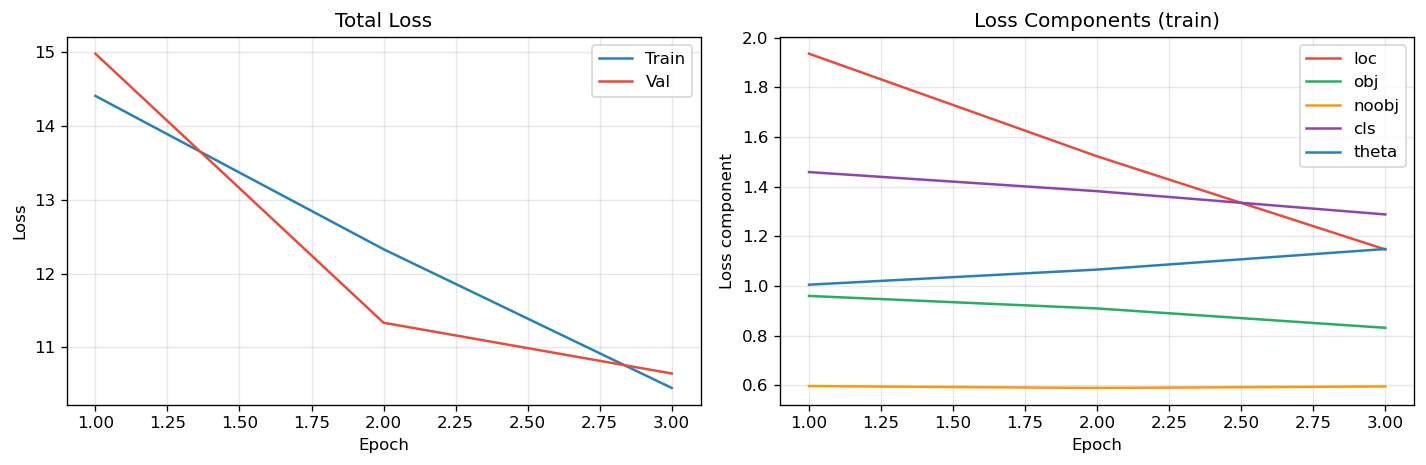

Left: train vs validation total loss. Right: train loss components for localization, objectness, background, class, and theta.


## Step 6 - Evaluation and Benchmarking

Evaluation is ellipse-aware:

- Predictions are decoded into ellipse parameters.
- Ellipse-NMS removes duplicate predictions.
- A prediction is correct only if the class matches and ellipse-IoU exceeds the threshold.
- Precision, recall, AP, and mAP are reported.

The saved results include `IoU = 0.5` and `IoU = 0.3`. The stricter threshold is the main metric; the looser threshold helps diagnose whether early models roughly localize objects but do not yet fit tight ellipses.


In [ ]:
# Evaluation metrics and visualization functions.
"""
EllipseNet — Evaluation & Visualisation
Computes: precision, recall, mAP (ellipse-IoU based)
Draws:    predicted ellipses on images with confidence + class labels
"""

import numpy as np
import os

os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/ellipsenet_matplotlib')

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse as MplEllipse


# ─────────────────────────────────────────────
# mAP computation
# ─────────────────────────────────────────────
def compute_ap(recalls, precisions):
    """Area under precision-recall curve (11-point interpolation)."""
    ap = 0.0
    for t in np.arange(0.0, 1.1, 0.1):
        p_at_r = precisions[recalls >= t]
        ap += p_at_r.max() if p_at_r.size > 0 else 0.0
    return ap / 11.0


def evaluate(model, dataset, n_classes,
             iou_thresh=0.5, conf_thresh=0.01,
             nms_thresh=0.4, n_mc_samples=200,
             batch_size=4):
    """
    Full evaluation loop.

    Returns dict with:
        precision, recall, mAP (per class + mean)
        all_detections, all_gt
    """
    all_detections = {c: [] for c in range(n_classes)}  # list of (score, tp, fp)
    n_gt = {c: 0 for c in range(n_classes)}

    for start in range(0, len(dataset), batch_size):
        end   = min(start + batch_size, len(dataset))
        batch = [dataset[i] for i in range(start, end)]
        imgs    = np.stack([b[0] for b in batch], axis=0)
        gt_list = [b[1] for b in batch]

        preds = model.predict(imgs, conf_thresh=conf_thresh,
                              nms_thresh=nms_thresh, n_samples=n_mc_samples)

        for ni, (pred, gts) in enumerate(zip(preds, gt_list)):
            # count GT per class
            for gt in gts:
                n_gt[gt['class_id']] += 1

            matched = set()
            boxes_pred   = pred['boxes']     # (M, 5)
            scores_pred  = pred['scores']    # (M,)
            classes_pred = pred['classes']   # (M,)

            for m in range(len(scores_pred)):
                c    = int(classes_pred[m])
                box  = boxes_pred[m]
                scr  = float(scores_pred[m])

                # find best matching GT of same class
                best_iou = -1
                best_j   = -1
                for j, gt in enumerate(gts):
                    if gt['class_id'] != c or j in matched:
                        continue
                    e2 = (gt['cx'], gt['cy'], gt['a'], gt['b'], gt['theta'])
                    iou = ellipse_iou_mc(tuple(box), e2, n_mc_samples)
                    if iou > best_iou:
                        best_iou = iou
                        best_j   = j

                if best_iou >= iou_thresh and best_j >= 0:
                    matched.add(best_j)
                    all_detections[c].append((scr, 1, 0))  # TP
                else:
                    all_detections[c].append((scr, 0, 1))  # FP

    # ── compute per-class AP ──────────────────────────────────────────
    class_aps = {}
    class_prec = {}
    class_rec  = {}
    for c in range(n_classes):
        dets = all_detections[c]
        if not dets or n_gt[c] == 0:
            class_aps[c]  = 0.0
            class_prec[c] = 0.0
            class_rec[c]  = 0.0
            continue
        dets_sorted = sorted(dets, key=lambda x: x[0], reverse=True)
        tp = np.cumsum([d[1] for d in dets_sorted])
        fp = np.cumsum([d[2] for d in dets_sorted])
        recalls    = tp / (n_gt[c] + 1e-9)
        precisions = tp / (tp + fp + 1e-9)
        class_aps[c]  = compute_ap(recalls, precisions)
        class_prec[c] = float(precisions[-1]) if len(precisions) else 0.0
        class_rec[c]  = float(recalls[-1])    if len(recalls)    else 0.0

    mAP = float(np.mean(list(class_aps.values())))

    results = {
        'mAP':       mAP,
        'class_APs': class_aps,
        'precision': {c: class_prec[c] for c in range(n_classes)},
        'recall':    {c: class_rec[c]  for c in range(n_classes)},
        'n_gt':      n_gt,
    }
    print(f"\nEvaluation Results (IoU threshold = {iou_thresh})")
    print(f"{'Class':>6} {'AP':>8} {'Prec':>8} {'Rec':>8} {'GT':>6}")
    print("─" * 42)
    for c in range(n_classes):
        print(f"{c:>6} {class_aps[c]:8.4f} {class_prec[c]:8.4f} {class_rec[c]:8.4f} {n_gt[c]:>6}")
    print("─" * 42)
    print(f"{'mAP':>6} {mAP:8.4f}")
    return results


# ─────────────────────────────────────────────
# Visualisation helpers
# ─────────────────────────────────────────────
CLASS_COLORS = [
    '#E74C3C', '#27AE60', '#2980B9', '#F39C12',
    '#8E44AD', '#16A085', '#D35400', '#2C3E50',
]

def draw_ellipse(ax, cx, cy, a, b, theta_rad, img_w, img_h,
                 color='red', linewidth=1.5, label=None, alpha=0.85):
    """Draw a single ellipse patch on a matplotlib Axes."""
    # convert normalised → pixels
    cx_px = cx * img_w
    cy_px = cy * img_h
    a_px  = a  * img_w
    b_px  = b  * img_h
    angle_deg = np.degrees(theta_rad)
    ellipse = MplEllipse(
        (cx_px, cy_px),
        width=2 * a_px, height=2 * b_px,
        angle=angle_deg,
        linewidth=linewidth,
        edgecolor=color, facecolor='none',
        alpha=alpha,
    )
    ax.add_patch(ellipse)
    # small orientation tick
    end_x = cx_px + a_px * np.cos(theta_rad)
    end_y = cy_px + a_px * np.sin(theta_rad)
    ax.plot([cx_px, end_x], [cy_px, end_y], color=color,
            linewidth=1.0, alpha=0.7)
    if label:
        offset = 3 if max(img_w, img_h) > 10 else 0.03
        label_y = max(0.02 * img_h, cy_px - b_px - offset)
        ax.text(cx_px, label_y, label,
                fontsize=6, color=color, ha='center',
                bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6, ec='none'))


def visualise_ellipse_iou(e1=(0.45, 0.50, 0.22, 0.10, 0.35),
                          e2=(0.55, 0.52, 0.20, 0.12, 0.95),
                          n_samples=4000,
                          out_path='figures/ellipse_iou_demo.png',
                          seed=7):
    """
    Visualize Monte Carlo ellipse-IoU between two normalized ellipses.

    Ellipse format: (cx, cy, a, b, theta), all normalized except theta radians.
    """
    rng = np.random.default_rng(seed)
    xs = rng.uniform(0.0, 1.0, n_samples)
    ys = rng.uniform(0.0, 1.0, n_samples)

    in1 = point_in_ellipse(xs, ys, *e1)
    in2 = point_in_ellipse(xs, ys, *e2)
    both = in1 & in2
    one = in1 ^ in2
    neither = ~(in1 | in2)
    iou = ellipse_iou_mc(e1, e2, n_samples=n_samples)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(xs[neither], ys[neither], s=3, color='#DDDDDD', alpha=0.35, label='outside')
    ax.scatter(xs[one], ys[one], s=4, color='#F39C12', alpha=0.55, label='union only')
    ax.scatter(xs[both], ys[both], s=5, color='#27AE60', alpha=0.7, label='intersection')
    draw_ellipse(ax, *e1, img_w=1, img_h=1, color='#2980B9', linewidth=2.0, label='E1')
    draw_ellipse(ax, *e2, img_w=1, img_h=1, color='#E74C3C', linewidth=2.0, label='E2')
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)
    ax.set_aspect('equal')
    ax.set_title(f'Ellipse IoU Monte Carlo = {iou:.4f}')
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(alpha=0.2)

    os.makedirs(os.path.dirname(out_path) or '.', exist_ok=True)
    plt.tight_layout()
    plt.savefig(out_path, dpi=140, bbox_inches='tight')
    plt.close()
    print(f"Ellipse IoU visualisation saved -> {out_path}")
    return iou


def visualise_predictions(model, dataset, n_images=8,
                          class_names=None, conf_thresh=0.3,
                          out_path='figures/predictions.png'):
    """
    Draw GT (green) and predicted (red) ellipses side-by-side for n_images.
    """
    n_images = min(n_images, len(dataset))
    fig, axes = plt.subplots(2, n_images, figsize=(3 * n_images, 6))
    if n_images == 1:
        axes = axes.reshape(2, 1)

    for col in range(n_images):
        img, gts = dataset[col]               # (3,H,W), list of dicts
        H, W = img.shape[1], img.shape[2]
        img_disp = img.transpose(1, 2, 0)     # H,W,3

        # run model
        inp  = img[None]                       # (1,3,H,W)
        pred = model.predict(inp, conf_thresh=conf_thresh)[0]

        for row, ax in enumerate(axes[:, col]):
            ax.imshow(np.clip(img_disp, 0, 1))
            ax.set_xlim(0, W); ax.set_ylim(H, 0)
            ax.axis('off')

            if row == 0:  # Ground Truth
                ax.set_title('Ground Truth', fontsize=7, pad=2)
                for gt in gts:
                    c = gt['class_id']
                    col_str = CLASS_COLORS[c % len(CLASS_COLORS)]
                    lbl = class_names[c] if class_names else str(c)
                    draw_ellipse(ax, gt['cx'], gt['cy'], gt['a'], gt['b'],
                                 gt['theta'], W, H, color=col_str, label=lbl)
            else:         # Predictions
                ax.set_title('Prediction', fontsize=7, pad=2)
                boxes   = pred['boxes']
                scores  = pred['scores']
                classes = pred['classes']
                for mi in range(len(scores)):
                    c       = int(classes[mi])
                    col_str = CLASS_COLORS[c % len(CLASS_COLORS)]
                    lbl = f"{class_names[c] if class_names else c} {scores[mi]:.2f}"
                    draw_ellipse(ax, *boxes[mi], W, H, color=col_str,
                                 label=lbl, linewidth=2)

    fig.suptitle('EllipseNet Predictions  ●  Green=GT  Red=Pred', fontsize=9)
    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path) or '.', exist_ok=True)
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.close()
    print(f"Prediction visualisation saved → {out_path}")


def plot_loss_curves(history, out_path='figures/loss_curves.png'):
    """Plot train/val loss curves from training history JSON."""
    epochs = [h['epoch'] for h in history]
    train_loss = [h['train']['total'] for h in history]
    val_loss   = [h['val']['total']   for h in history if 'val' in h]
    val_epochs = [h['epoch']          for h in history if 'val' in h]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Total loss
    ax = axes[0]
    ax.plot(epochs, train_loss, label='Train', color='#2980B9', linewidth=1.5)
    if val_loss:
        ax.plot(val_epochs, val_loss, label='Val', color='#E74C3C', linewidth=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title('Total Loss'); ax.legend(); ax.grid(alpha=0.3)

    # Component losses
    ax = axes[1]
    components = ['loc', 'obj', 'noobj', 'cls', 'theta']
    colours    = ['#E74C3C','#27AE60','#F39C12','#8E44AD','#2980B9']
    for comp, col in zip(components, colours):
        vals = [h['train'].get(comp, 0) for h in history]
        ax.plot(epochs, vals, label=comp, color=col, linewidth=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss component')
    ax.set_title('Loss Components (train)'); ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path) or '.', exist_ok=True)
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.close()
    print(f"Loss curves saved → {out_path}")


def plot_pr_curves(eval_results, n_classes, class_names=None,
                   out_path='figures/pr_curves.png'):
    """Bar chart of per-class AP."""
    aps = [eval_results['class_APs'].get(c, 0) for c in range(n_classes)]
    names = class_names if class_names else [f'cls_{c}' for c in range(n_classes)]

    fig, ax = plt.subplots(figsize=(max(6, n_classes * 1.2), 4))
    bars = ax.bar(names, aps, color=CLASS_COLORS[:n_classes])
    ax.axhline(eval_results['mAP'], color='black', linestyle='--',
               linewidth=1.5, label=f"mAP = {eval_results['mAP']:.4f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Average Precision (AP)')
    ax.set_title(f"Per-Class AP  (mAP = {eval_results['mAP']:.4f})")
    ax.legend(); ax.grid(axis='y', alpha=0.3)

    # value labels on bars
    for bar, v in zip(bars, aps):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path) or '.', exist_ok=True)
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.close()
    print(f"PR bar chart saved → {out_path}")


def plot_failure_analysis(model, dataset, n_images=6, conf_thresh=0.3,
                          out_path='figures/failure_cases.png'):
    """
    Show images where detection failed (missed / false positive).
    Missed: GT with no matching prediction.
    FP: prediction with no matching GT.
    """
    cases = []
    for i in range(len(dataset)):
        img, gts = dataset[i]
        inp  = img[None]
        pred = model.predict(inp, conf_thresh=conf_thresh)[0]
        if len(pred['scores']) == 0 and len(gts) > 0:
            cases.append((img, gts, pred, 'Missed'))
        elif len(pred['scores']) > 0 and len(gts) == 0:
            cases.append((img, gts, pred, 'False Positive'))
        if len(cases) >= n_images:
            break

    if not cases:
        print("No clear failure cases found (model performing well or no examples).")
        return

    n = min(len(cases), n_images)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1:
        axes = [axes]

    for ax, (img, gts, pred, case_type) in zip(axes, cases):
        H, W = img.shape[1], img.shape[2]
        ax.imshow(np.clip(img.transpose(1,2,0), 0, 1))
        ax.set_xlim(0, W); ax.set_ylim(H, 0)
        ax.axis('off')
        ax.set_title(case_type, fontsize=7, color='red' if 'FP' in case_type else 'orange')
        for gt in gts:
            draw_ellipse(ax, gt['cx'], gt['cy'], gt['a'], gt['b'],
                         gt['theta'], W, H, color='green')
        for mi in range(len(pred['scores'])):
            draw_ellipse(ax, *pred['boxes'][mi], W, H, color='red')

    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path) or '.', exist_ok=True)
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.close()
    print(f"Failure analysis saved → {out_path}")


In [ ]:
# Extra notebook visualization helpers used to regenerate sample grids and overlays.
def _ensure_dirs():
    os.makedirs("figures", exist_ok=True)
    os.makedirs("outputs", exist_ok=True)


def _image_hw(img):
    return img.shape[1], img.shape[2]


def _show_image(ax, img):
    ax.imshow(np.clip(img.transpose(1, 2, 0), 0, 1))
    h, w = _image_hw(img)
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.axis("off")


def _draw_box_proxy(ax, target, width, height, color="#555555"):
    cx = target["cx"] * width
    cy = target["cy"] * height
    a = target["a"] * width
    b = target["b"] * height
    rect = patches.Rectangle(
        (cx - a, cy - b),
        2 * a,
        2 * b,
        fill=False,
        edgecolor=color,
        linewidth=1.2,
        linestyle="--",
        alpha=0.75,
    )
    ax.add_patch(rect)


def plot_raw_samples(dataset, class_names, out_path="figures/voc_sample_images.png", n_images=8):
    n_images = min(n_images, len(dataset))
    cols = 4
    rows = int(np.ceil(n_images / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for idx in range(n_images):
        img, targets = dataset[idx]
        ax = axes[idx]
        _show_image(ax, img)
        info = dataset.sample_info(idx)
        labels = sorted({class_names[t["class_id"]] for t in targets})
        ax.set_title(f"{info['image_id']} | {', '.join(labels)}", fontsize=8)

    fig.suptitle("Pascal VOC samples used by EllipseNet", fontsize=12)
    plt.tight_layout()
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.close()


def plot_annotation_conversion(dataset, class_names, out_path="figures/annotation_conversion_demo.png"):
    img, targets = dataset[0]
    h, w = _image_hw(img)
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))

    titles = ["Original image", "VOC box proxy", "Converted ellipse target"]
    for ax, title in zip(axes, titles):
        _show_image(ax, img)
        ax.set_title(title, fontsize=9)

    for target in targets:
        c = target["class_id"]
        color = CLASS_COLORS[c % len(CLASS_COLORS)]
        label = class_names[c]
        _draw_box_proxy(axes[1], target, w, h, color=color)
        draw_ellipse(
            axes[2],
            target["cx"],
            target["cy"],
            target["a"],
            target["b"],
            target["theta"],
            w,
            h,
            color=color,
            label=label,
        )

    plt.tight_layout()
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.close()


def plot_gt_overlays(dataset, class_names, out_path="figures/voc_ellipse_overlays.png", n_images=6):
    n_images = min(n_images, len(dataset))
    fig, axes = plt.subplots(2, 3, figsize=(10, 6.5))
    axes = axes.reshape(-1)

    for idx in range(n_images):
        img, targets = dataset[idx]
        h, w = _image_hw(img)
        ax = axes[idx]
        _show_image(ax, img)
        for target in targets:
            c = target["class_id"]
            color = CLASS_COLORS[c % len(CLASS_COLORS)]
            draw_ellipse(
                ax,
                target["cx"],
                target["cy"],
                target["a"],
                target["b"],
                target["theta"],
                w,
                h,
                color=color,
                label=class_names[c],
            )
        ax.set_title(dataset.sample_info(idx)["image_id"], fontsize=8)

    fig.suptitle("Ground-truth ellipse overlays", fontsize=12)
    plt.tight_layout()
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.close()


def plot_rotation_grid(voc_root, class_names, out_path="figures/voc_rotation_samples.png"):
    ds = VOCEllipseDataset(
        voc_root=voc_root,
        split="train",
        selected_classes=class_names,
        img_size=96,
        rotation_angles=(0.0, -20.0, -10.0, 10.0, 20.0),
        max_images=1,
    )
    fig, axes = plt.subplots(1, len(ds), figsize=(13, 3))
    for idx, ax in enumerate(axes):
        img, targets = ds[idx]
        h, w = _image_hw(img)
        _show_image(ax, img)
        for target in targets:
            c = target["class_id"]
            draw_ellipse(
                ax,
                target["cx"],
                target["cy"],
                target["a"],
                target["b"],
                target["theta"],
                w,
                h,
                color=CLASS_COLORS[c % len(CLASS_COLORS)],
                label=class_names[c],
            )
        angle = ds.sample_info(idx)["rotation_angle_deg"]
        ax.set_title(f"{angle:+.0f} deg", fontsize=9)
    fig.suptitle("Deterministic rotation augmentation with updated ellipse centers/theta", fontsize=12)
    plt.tight_layout()
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.close()


def plot_anchor_grid(out_path="figures/ellipse_anchor_grid.png"):
    anchors = np.array([[0.10, 0.07], [0.20, 0.14]])
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
    for gy in range(8):
        for gx in range(8):
            ax.add_patch(
                patches.Rectangle((gx / 8, gy / 8), 1 / 8, 1 / 8, fill=False, linewidth=0.4, edgecolor="#AAAAAA")
            )
    centers = [(0.31, 0.31), (0.69, 0.31), (0.31, 0.69), (0.69, 0.69)]
    angles = [0.0, 0.6, 1.1, 2.2]
    for i, ((cx, cy), theta) in enumerate(zip(centers, angles)):
        a, b = anchors[i % len(anchors)]
        draw_ellipse(ax, cx, cy, a, b, theta, 1, 1, color=CLASS_COLORS[i], linewidth=2.0, label=f"anchor {i % 2}")
    ax.set_title("S x S grid cells with B elliptical anchors per cell", fontsize=10)
    plt.tight_layout()
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.close()


def write_iou_table(out_path="outputs/ellipse_iou_examples.json"):
    examples = {
        "same_ellipse": ellipse_iou_mc((0.5, 0.5, 0.20, 0.10, 0.0), (0.5, 0.5, 0.20, 0.10, 0.0), 5000),
        "shifted": ellipse_iou_mc((0.45, 0.5, 0.20, 0.10, 0.0), (0.55, 0.5, 0.20, 0.10, 0.0), 5000),
        "rotated": ellipse_iou_mc((0.5, 0.5, 0.22, 0.08, 0.0), (0.5, 0.5, 0.22, 0.08, 1.0), 5000),
    }
    with open(out_path, "w") as f:
        json.dump({k: float(v) for k, v in examples.items()}, f, indent=2)


def regenerate_existing_plots(model, val_ds, class_names):
    if os.path.exists("outputs/train_log.json"):
        with open("outputs/train_log.json") as f:
            history = json.load(f)
        plot_loss_curves(history, out_path="figures/loss_curves.png")

    if os.path.exists("outputs/eval_results.json"):
        with open("outputs/eval_results.json") as f:
            results = json.load(f)
        eval_block = results.get("iou_0_5", results)
        if "class_APs" in eval_block:
            eval_block["class_APs"] = {int(k): v for k, v in eval_block["class_APs"].items()}
        plot_pr_curves(eval_block, n_classes=len(class_names), class_names=class_names, out_path="figures/pr_curves.png")

    visualise_ellipse_iou(out_path="figures/ellipse_iou_demo.png")
    visualise_predictions(
        model,
        val_ds,
        n_images=min(6, len(val_ds)),
        class_names=class_names,
        conf_thresh=0.05,
        out_path="figures/predictions.png",
    )


def main():
    _ensure_dirs()
    voc_root = os.environ.get("VOC_ROOT", "../archive/VOC2012_train_val/VOC2012_train_val")
    class_names = list(DEFAULT_SELECTED_CLASSES)

    train_ds = VOCEllipseDataset(
        voc_root=voc_root,
        split="train",
        selected_classes=class_names,
        img_size=96,
        rotation_angles=(0.0,),
        max_images=12,
    )
    val_ds = VOCEllipseDataset(
        voc_root=voc_root,
        split="val",
        selected_classes=class_names,
        img_size=64,
        rotation_angles=(0.0,),
        max_images=12,
    )

    model = EllipseNet(img_size=64, S=8, B=2, C=len(class_names))
    checkpoint = "checkpoints/best_model.npz"
    if os.path.exists(checkpoint):
        model.load(checkpoint)

    plot_raw_samples(train_ds, class_names)
    plot_annotation_conversion(train_ds, class_names)
    plot_gt_overlays(train_ds, class_names)
    plot_rotation_grid(voc_root, class_names)
    plot_anchor_grid()
    write_iou_table()
    regenerate_existing_plots(model, val_ds, class_names)

    print("Generated notebook figures in EllipseNet_Complete/figures")


In [ ]:

# Embedded fallback metrics so the metric table and PR graph can display before recomputation.
EMBEDDED_RESULTS = {
    "iou_0_5": {
        "mAP": 0.000374093209316001,
        "class_APs": {
            "0": 0.0009143155694866696,
            "1": 0.0001252191334834238,
            "2": 8.274492497790958e-05
        },
        "precision": {
            "0": 0.005314908317830811,
            "1": 0.0003884098500737677,
            "2": 0.0003956739646530736
        },
        "recall": {
            "0": 0.07462686567150256,
            "1": 0.07692307692189349,
            "2": 0.08823529411505192
        },
        "n_gt": {
            "0": 536,
            "1": 65,
            "2": 34
        }
    },
    "iou_0_3": {
        "mAP": 0.009033236007156461,
        "class_APs": {
            "0": 0.022980393786226273,
            "1": 0.0020979955895942025,
            "2": 0.0020213186456489083
        },
        "precision": {
            "0": 0.02834331337324972,
            "1": 0.0017810128542665494,
            "2": 0.001851851851851607
        },
        "recall": {
            "0": 0.39738805970075114,
            "1": 0.35384615384071005,
            "2": 0.4117647058702423
        },
        "n_gt": {
            "0": 536,
            "1": 65,
            "2": 34
        }
    }
}

if os.path.exists('checkpoints/best_model.npz'):
    model.load('checkpoints/best_model.npz')

RUN_EVALUATION = False
if RUN_EVALUATION:
    results_50 = evaluate(model, val_ds, n_classes=C, iou_thresh=0.5, conf_thresh=0.05, batch_size=4)
    results_30 = evaluate(model, val_ds, n_classes=C, iou_thresh=0.3, conf_thresh=0.05, batch_size=4)
    results = {'iou_0_5': results_50, 'iou_0_3': results_30}
    with open('outputs/eval_results.json', 'w') as f:
        json.dump(results, f, indent=2)
elif os.path.exists('outputs/eval_results.json'):
    with open('outputs/eval_results.json') as f:
        results = json.load(f)
else:
    results = EMBEDDED_RESULTS

results


In [ ]:

def by_class(metric_dict, class_id):
    return metric_dict.get(class_id, metric_dict.get(str(class_id), 0.0))

def metric_rows(results_block):
    rows = []
    for threshold, block in results_block.items():
        rows.append({
            'threshold': threshold,
            'mAP': block['mAP'],
            'precision_person': by_class(block['precision'], 0),
            'recall_person': by_class(block['recall'], 0),
            'precision_car': by_class(block['precision'], 1),
            'recall_car': by_class(block['recall'], 1),
            'precision_dog': by_class(block['precision'], 2),
            'recall_dog': by_class(block['recall'], 2),
        })
    return rows

metric_rows(results)


## Saved Evaluation Metrics

These are the saved CPU-run metrics embedded for readability before re-execution.

| Threshold | mAP | Person Prec | Person Rec | Car Prec | Car Rec | Dog Prec | Dog Rec |
|---|---:|---:|---:|---:|---:|---:|---:|
| `iou_0_5` | 0.000374 | 0.005315 | 0.074627 | 0.000388 | 0.076923 | 0.000396 | 0.088235 |
| `iou_0_3` | 0.009033 | 0.028343 | 0.397388 | 0.001781 | 0.353846 | 0.001852 | 0.411765 |


### Per-Class AP and mAP

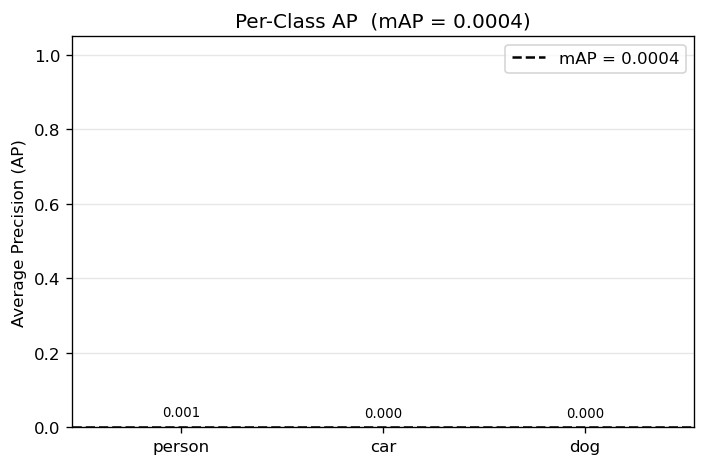

Per-class AP values are plotted with the mean AP shown as a dashed reference line.


### Ground Truth vs Predicted Ellipses

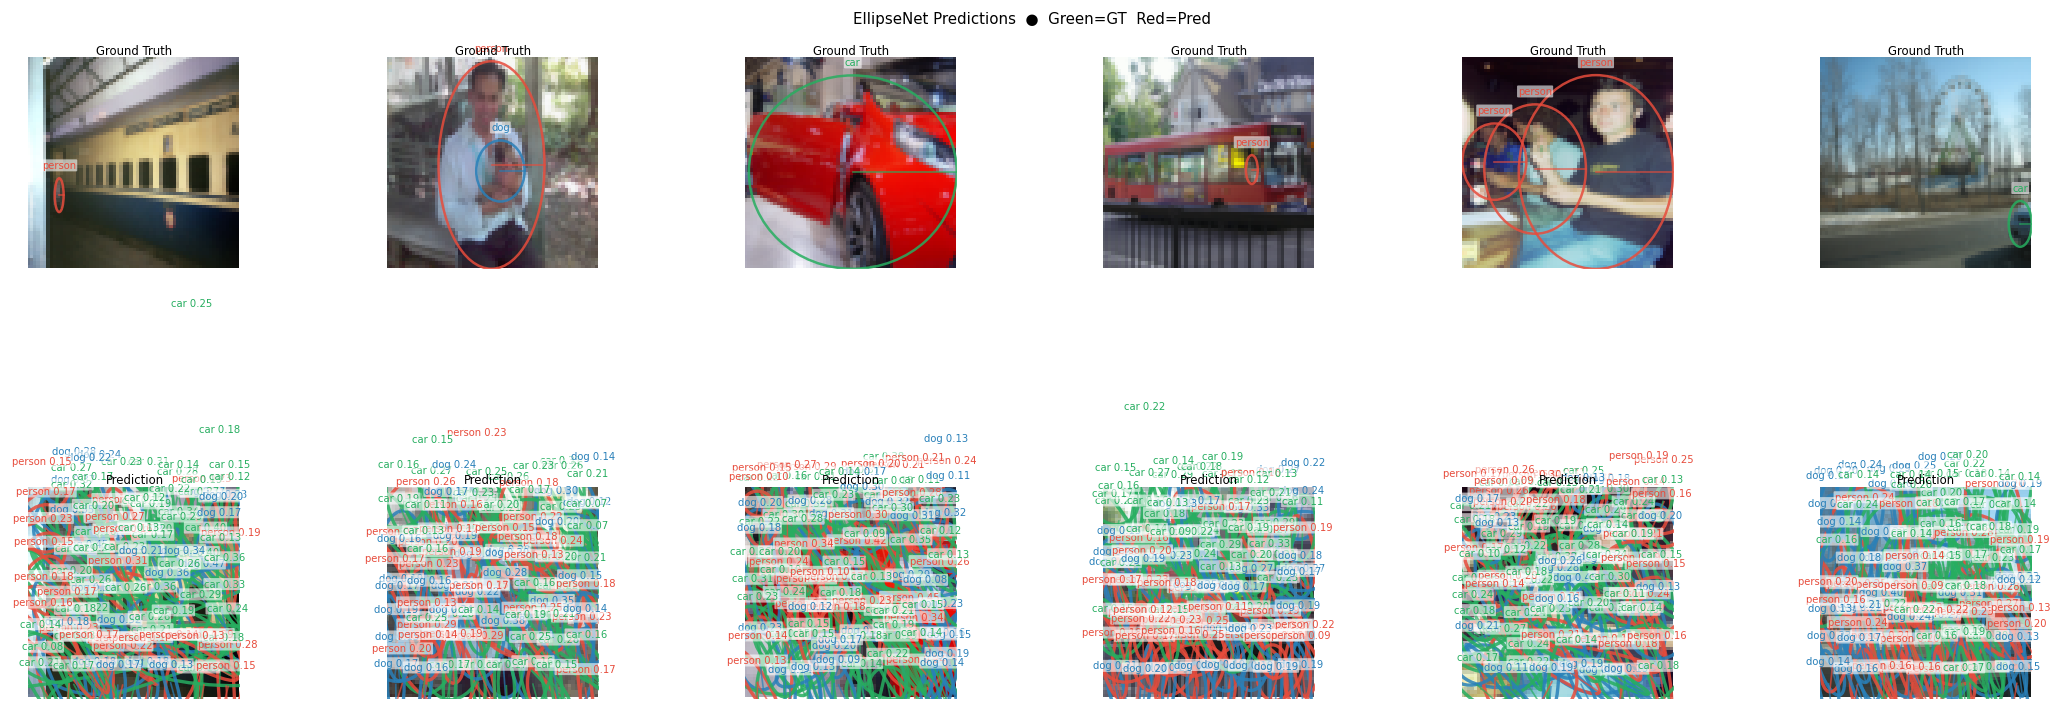

The top row shows ground truth ellipses; the bottom row shows model predictions after decoding and NMS.


In [ ]:

# Regenerate all notebook figures if needed.
REGENERATE_FIGURES = False
if REGENERATE_FIGURES:
    plot_raw_samples(VOCEllipseDataset(VOC_ROOT, 'train', CLASS_NAMES, img_size=96, rotation_angles=(0.0,), max_images=12), CLASS_NAMES)
    plot_annotation_conversion(VOCEllipseDataset(VOC_ROOT, 'train', CLASS_NAMES, img_size=96, rotation_angles=(0.0,), max_images=12), CLASS_NAMES)
    plot_gt_overlays(VOCEllipseDataset(VOC_ROOT, 'train', CLASS_NAMES, img_size=96, rotation_angles=(0.0,), max_images=12), CLASS_NAMES)
    plot_rotation_grid(VOC_ROOT, CLASS_NAMES)
    plot_anchor_grid()
    write_iou_table()
    plot_loss_curves(history, out_path='figures/loss_curves.png')
    eval_block = results['iou_0_5']
    eval_block_for_plot = dict(eval_block)
    eval_block_for_plot['class_APs'] = {int(k): v for k, v in eval_block['class_APs'].items()}
    plot_pr_curves(eval_block_for_plot, n_classes=C, class_names=CLASS_NAMES, out_path='figures/pr_curves.png')
    visualise_ellipse_iou(out_path='figures/ellipse_iou_demo.png')
    visualise_predictions(model, val_ds, n_images=min(6, len(val_ds)), class_names=CLASS_NAMES, conf_thresh=0.05, out_path='figures/predictions.png')


## Discussion and Failure Analysis

The logged run is short and CPU-friendly, so the mAP is low. That is expected for a from-scratch NumPy detector trained for only a few epochs. The main evidence here is that the complete ellipse pipeline works: annotations convert, images rotate with updated theta, the CNN forwards/backwards, loss decreases, predictions decode to ellipses, and evaluation uses ellipse-IoU.

Likely failure modes after short training:

- **Loose ellipses:** centers may be near the object, but `a`, `b`, or `theta` are not tight enough for `IoU = 0.5`.
- **Orientation instability:** angle learning can lag behind objectness and center learning.
- **False positives:** a low confidence threshold keeps many candidate ellipses.
- **Missed detections:** small or occluded objects may not activate the correct cell/anchor.

A stronger final run would increase dataset size, epochs, and possibly image resolution, while keeping the same NumPy-only implementation.


## Reproduction Notes

To run locally from the repo root:

```bash
python3 -m venv .venv
.venv/bin/python -m pip install -r EllipseNet_Complete/requirements.txt
cd EllipseNet_Complete
../.venv/bin/python -m jupyter notebook EllipseNet_Final.ipynb
```

The notebook itself is self-contained for grading. The separate `.py` files are retained only as reusable source files; the notebook does not require importing them.


In [ ]:

summary = {
    'project': 'EllipseNet',
    'constraint': 'NumPy-only CNN, manual forward/backward/update; no autograd frameworks',
    'dataset': 'Pascal VOC 2012',
    'classes': CLASS_NAMES,
    'output_geometry': '[confidence, cx, cy, a, b, theta, class logits]',
    'grid_size': S,
    'anchors_per_cell': B,
    'metrics': results,
}
summary
